# Targeted Temperature Management After Resuscitation: Identifying Beneficial Patient Groups

This exploratory analysis aims to investigate which patient groups benefit from Targeted Temperature Management (TTM) after achieving Return of Spontaneous Circulation (ROSC) following cardiac arrest. Using data from the **I-CARE: International Cardiac Arrest REsearch consortium Database**, we will explore patterns and potential insights in patient outcomes.

## Dataset Information

We are using the I-CARE dataset, which contains extensive clinical information on patients who experienced cardiac arrest and underwent TTM. This analysis will focus on evaluating patient subgroups and determining any correlations between clinical variables and patient outcomes.

### Citation

When using this resource, please cite the following:

- Amorim, E., Zheng, W., Lee, J. W., Herman, S., Ghassemi, M., Sivaraju, A., Gaspard, N., Hofmeijer, J., van Putten, M. J. A. M., Reyna, M., Clifford, G., & Westover, B. (2023). I-CARE: International Cardiac Arrest REsearch consortium Database (version 2.1). PhysioNet. https://doi.org/10.13026/m33r-bj81.
  
Additionally, please cite the original publication:

- Amorim, E., Zheng, W., Ghassemi, M., Aghaeeaval, M., Kandhare, P., Karukonda, V., Lee, J. W., Herman, S. T., Sivaraju, A., Gaspard, N., Hofmeijer, J., van Putten, M. J. A. M., Sameni, R., Reyna, M. A., Clifford, G. D., & Westover, M. B. (2023). The International Cardiac Arrest Research Consortium Electroencephalography Database. Critical Care Medicine. https://doi.org/10.1097/CCM.0000000000006074.

Please also include the standard citation for PhysioNet:

- Goldberger, A., Amaral, L., Glass, L., Hausdorff, J., Ivanov, P. C., Mark, R., ... & Stanley, H. E. (2000). PhysioBank, PhysioToolkit, and PhysioNet: Components of a new research resource for complex physiologic signals. Circulation [Online]. 101 (23), pp. e215–e220.

## Clinical Data Description

| **Feature**         | **Description**                                                                                   | **Value Range**                              | **Data Type** |
|---------------------|---------------------------------------------------------------------------------------------------|----------------------------------------------|---------------|
| Age                 | Patient age in years                                                                               | Numeric                                      | Number        |
| Sex                 | Patient sex                                                                                        | Male, Female                                 | Categorical   |
| Hospital            | The hospital where the patient was treated                                                         | A, B, C, D, E, F                             | Categorical   |
| ROSC                | Time from cardiac arrest to return of spontaneous circulation                                       | Time (minutes)                               | Number        |
| OHCA                | Whether the cardiac arrest occurred out of hospital                                                | True (out-of-hospital), False (in-hospital)  | Boolean       |
| Shockable Rhythm    | Whether the cardiac arrest had a shockable rhythm                                                  | True, False                                  | Boolean       |
| TTM                 | Targeted temperature management applied (in degrees Celsius)                                       | 33, 36, NaN (no TTM applied)                 | Number/NaN    |
| Outcome             | Patient's neurological outcome                                                                     | Good (CPC 1-2), Poor (CPC 3-5)               | Categorical   |
| CPC                 | Cerebral Performance Category score (ordinal scale)                                                | 1-5                                          | Ordinal       |
|                     | **CPC 1**: good neurological function, independent for daily living                                |                                              |               |
|                     | **CPC 2**: moderate neurological disability, independent for daily living                          |                                              |               |
|                     | **CPC 3**: severe neurological disability                                                          |                                              |               |
|                     | **CPC 4**: unresponsive wakefulness syndrome (vegetative state)                                    |                                              |               |
|                     | **CPC 5**: dead                                                                                   |                                              |               |
|                     | **Good outcome**: CPC 1 or 2                                                                       |                                              |               |
|                     | **Poor outcome**: CPC 3, 4, or 5                                                                   |                                              |               |

---

This analysis will explore these clinical features to identify trends and patterns associated with outcomes in post-cardiac arrest patients.


## Table of Contents

### 1. Data Cleanup and Preparation
1.1 **Load the Data**  
1.2 **Check and Adjust Datatypes, Column Headers, and Drop Unneeded Columns**  
1.3 **Check for Missing Values and Duplicates**  
1.4 **Handle Missing Values** !! Removed due to Data Leakage
1.5 **Check Corrected Data and Perform Initial Descriptive Analysis**  

### 2. Exploratory Data Analysis (EDA)
2.0 **Understanding the Demographics – Age and Gender Distribution**  
2.1 **Analysis of the Distribution of Good and Bad Outcomes**  
2.2 **Feature Distribution Across the Dataset**  
2.3 **Feature Distribution Overview for Good and Bad Outcomes**  
2.4 **What is the Distribution of Age Among Patients, and Does It Vary by Outcome?**  
2.5 **Is There a Relationship Between ROSC (Return of Spontaneous Circulation) Time and Patient Outcome?**  
2.6 **How Does the Application of TTM (Targeted Temperature Management) Vary Across Patient Outcomes?**  
2.7 **Does the Presence of a Shockable Rhythm Affect the Patient’s Outcome?**  
2.8 **What is the Distribution of Cerebral Performance Category (CPC) Scores in the Patient Population?**

## Data Cleanup and Preparation

In this section, we prepare the data for the upcoming **Exploratory Data Analysis (EDA)**. The following steps are carried out to ensure the dataset is clean, consistent, and ready for in-depth analysis:


### Table of Contents: 

#### a) Load the data
- Loading the dataset for analysis.

#### b) Check the datatypes, change column headers, and drop unneeded columns
- Verify and correct datatypes.
- Rename column headers for consistency.
- Remove unnecessary columns that are not relevant for the analysis.

#### c) Check for null/NA values and duplicates
- Identify missing values in the dataset.
- Check for and handle duplicate records.

#### d) Handle missing values
- Impute or remove missing data based on the nature of the feature.

#### e) Check the corrected data and perform a first descriptive analysis
- Review the data after cleanup.
- Conduct initial descriptive analysis to understand the basic statistics of the dataset.


In [46]:
# Numeric analysis
import numpy as np
import pandas as pd

# Save the data in a rich format
import pickle

### a) Load the data

In [47]:
# Load the csv file into a dataframe, provide context on true and false values
data = pd.read_csv("data/raw_patient_data.csv", true_values =["Yes"], false_values=["No"])
data.head()

,Patient,Hospital,Age,Sex,ROSC,OHCA,Shockable Rhythm,TTM,Outcome,CPC
0,284,A,53.0,Male,NaN,True,True,33.0,Good,1
1,286,F,85.0,Female,7.0,False,False,NaN,Good,1
2,296,A,48.0,Male,NaN,True,True,36.0,Good,1
3,299,A,45.0,Male,NaN,True,True,33.0,Good,1
4,303,D,51.0,Male,24.0,True,True,33.0,Good,1


### b) Check the datatypes and change datatypes and column headers and drop unneeded columns

In [48]:
# Check the datatypes of the loaded data
data.dtypes

Patient               int64
Hospital             object
Age                 float64
Sex                  object
ROSC                float64
OHCA                 object
Shockable Rhythm     object
TTM                 float64
Outcome              object
CPC                   int64
dtype: object

In [49]:
# Explicitly convert the nominal categorical variables, that were objects before
data['Hospital'] = data['Hospital'].astype("category")
data['Sex'] = data['Sex'].astype("category")
data['OHCA'] = data['OHCA'].astype("category")
data['Shockable Rhythm'] = data['Shockable Rhythm'].astype("category")
data['Outcome'] = data['Outcome'].astype("category")

# Define the order of values for the 'cpc' column
cpc_order = [1, 2, 3, 4, 5]

# Convert 'cpc' to an ordinal category
data['CPC'] = pd.Categorical(data['CPC'], categories=cpc_order, ordered=True)

# Replace the column names and store it in the same variable name
data = data.rename(columns={
                            "Hospital": "hospital",
                            "Age": "age",
                            "Sex": "sex",
                            "ROSC": "rosc",
                            "OHCA": "ohca",
                            "Shockable Rhythm": "shockable_rhythm",
                            "TTM": "ttm",
                            "Outcome": "outcome", 
                            "CPC": "cpc"
                            })


data.head()


,Patient,hospital,age,sex,rosc,ohca,shockable_rhythm,ttm,outcome,cpc
0,284,A,53.0,Male,NaN,True,True,33.0,Good,1
1,286,F,85.0,Female,7.0,False,False,NaN,Good,1
2,296,A,48.0,Male,NaN,True,True,36.0,Good,1
3,299,A,45.0,Male,NaN,True,True,33.0,Good,1
4,303,D,51.0,Male,24.0,True,True,33.0,Good,1


In [50]:
data.dtypes

Patient                int64
hospital            category
age                  float64
sex                 category
rosc                 float64
ohca                category
shockable_rhythm    category
ttm                  float64
outcome             category
cpc                 category
dtype: object

In [51]:
# Check if there are different types within a column
for col in data.columns:
    if data[col].apply(type).nunique() > 1:
        print(f"Column '{col}' has mixed types: {data[col].apply(type).unique()}")

### c) Check if null / na values are present and if duplicates are present

In [52]:
# Count missing values per feature
data.isnull().sum()

Patient               0
hospital              0
age                   1
sex                   3
rosc                304
ohca                 41
shockable_rhythm     32
ttm                  98
outcome               0
cpc                   0
dtype: int64

### d) Handle missing values

The missing values should be handled according to the type, the number of missing values and if information might be in the presence of missing values.

!! Handling of missing values is moved to a later place to avoid data leakage !!

In [53]:
# 1. For 'age' (numeric columns), impute with mean
#data['age'].fillna(data['age'].mean(), inplace=True)

# 2. For categorical variables 'sex', impute with the mode
#data['sex'].fillna(data['sex'].mode()[0], inplace=True)

# 3. Create binary flag columns to indicate missing values for 'rosc' and 'shockable_rhythm'
data['rosc_missing'] = data['rosc'].isnull().astype(int)
data['shockable_rhythm_missing'] = data['shockable_rhythm'].isnull().astype(int)

# 4. Ensure 'rosc' column has all missing values as np.nan
data['rosc'] = data['rosc'].where(data['rosc'].notna(), np.nan)

# 5. Add a new category for 'shockable_rhythm'
data['shockable_rhythm'] = data['shockable_rhythm'].cat.add_categories('Unknown')
data['shockable_rhythm'].fillna('Unknown', inplace=True)

# 6. Add a new category for 'ohca'
data['ohca'] = data['ohca'].astype('category')
data['ohca'] = data['ohca'].cat.add_categories('Unknown')
data['ohca'].fillna('Unknown', inplace=True)

# 7. Change 'ttm' to categorical and add a ew category
data['ttm'] = data['ttm'].astype('category')
data['ttm'] = data['ttm'].cat.add_categories('No TTM')
data['ttm'].fillna('No TTM', inplace=True)

# Count missing values per feature again
data.isnull().sum()

C:\Users\kentf\AppData\Local\Temp\ipykernel_14492\1327254874.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['shockable_rhythm'].fillna('Unknown', inplace=True)
C:\Users\kentf\AppData\Local\Temp\ipykernel_14492\1327254874.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

Patient                       0
hospital                      0
age                           1
sex                           3
rosc                        304
ohca                          0
shockable_rhythm              0
ttm                           0
outcome                       0
cpc                           0
rosc_missing                  0
shockable_rhythm_missing      0
dtype: int64

In [54]:
data

,Patient,hospital,age,sex,rosc,ohca,shockable_rhythm,ttm,outcome,cpc,rosc_missing,shockable_rhythm_missing
0,284,A,53.0,Male,NaN,True,True,33.0,Good,1,1,0
1,286,F,85.0,Female,7.0,False,False,No TTM,Good,1,0,0
2,296,A,48.0,Male,NaN,True,True,36.0,Good,1,1,0
3,299,A,45.0,Male,NaN,True,True,33.0,Good,1,1,0
4,303,D,51.0,Male,24.0,True,True,33.0,Good,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
602,1016,E,87.0,Male,7.0,True,False,33.0,Poor,5,0,0
603,1017,F,26.0,Male,52.0,True,False,No TTM,Poor,5,0,0
604,1018,E,63.0,Male,NaN,True,True,36.0,Poor,5,1,0
605,1019,A,72.0,Male,NaN,True,True,36.0,Good,1,1,0


### e) Check the corrected data and performe a first descriptive analysis

As the headers were corrected, unnecessary columns were dropped, missing data and duplicates were dropped, a first descriptive analysis can be performed.

In [55]:
# Perform full descriptive analysis of the dataset
data.describe(include='all')

,Patient,hospital,age,sex,rosc,ohca,shockable_rhythm,ttm,outcome,cpc,rosc_missing,shockable_rhythm_missing
count,607.000000,607,606.000000,604,303.000000,607,607,607.0,607,607.0,607.000000,607.000000
unique,NaN,5,NaN,2,NaN,3,3,3.0,2,5.0,NaN,NaN
top,NaN,A,NaN,Male,NaN,True,True,33.0,Poor,5.0,NaN,NaN
freq,NaN,261,NaN,417,NaN,442,297,448.0,382,353.0,NaN,NaN
mean,668.588138,NaN,61.168317,NaN,23.267327,NaN,NaN,NaN,NaN,NaN,0.500824,0.052718
std,204.331564,NaN,15.650355,NaN,18.794052,NaN,NaN,NaN,NaN,NaN,0.500412,0.223655
min,284.000000,NaN,16.000000,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
25%,488.500000,NaN,52.000000,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
50%,673.000000,NaN,63.000000,NaN,19.000000,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000
75%,846.500000,NaN,72.000000,NaN,30.000000,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000


The dataset is now ready to be further evaluated. All remaining features are possibly meaningful to the analysis and provided adequat data.

### f) Save the data to a new file

As the general cleaning has been performed, we should save the data to a new file, that can be used for further tasks.

In [56]:
# Save the DataFrame to a Pickle file
with open('data/patient_data.pkl', 'wb') as f:
    pickle.dump(data, f)

# Confirmation message
print("DataFrame has been saved to 'data/patient_data.pkl'")

DataFrame has been saved to 'data/patient_data.pkl'


## Exploratory Data Analysis (EDA)

After completing the data cleanup and preparation, we now proceed with the **Exploratory Data Analysis (EDA)** to gain insights into the dataset. This section aims to explore key variables, relationships between clinical factors, and their influence on patient outcomes. The following subsections provide detailed visualizations and analysis of the dataset's features and outcomes.

### Table of Contents

#### 0: Understanding the Demographics – Age and Gender Distribution
- Proportion of Male and Female Patients
- Proportion of Age Buckets (10-year Range)
- Age and Gender Distribution by Outcome

#### 1: Analysis of the Distribution of Good and Bad Outcomes
- Overall Outcome Distribution

#### 2: Feature Distribution Across the Dataset
- Distributions of All Features (Numerical and Categorical)

#### 3: Feature Distribution Overview for Good and Bad Outcomes
- Comparative Distribution of Features (Age, ROSC, OHCA, etc.) for Good and Bad Outcomes

#### 4: What is the Distribution of Age Among Patients, and Does It Vary by Outcome?
- Overall Age Distribution
- Age Distribution by Outcome (Good vs Poor)

#### 5: Is There a Relationship Between ROSC (Return of Spontaneous Circulation) Time and Patient Outcome?
- ROSC Time by Outcome
- ROSC Time Distribution for Missing Values

#### 6: How Does the Application of TTM (Targeted Temperature Management) Vary Across Patient Outcomes?
- TTM Application by Outcome
- Percentage Distribution of Outcomes within Each TTM Category

#### 7: Does the Presence of a Shockable Rhythm Affect the Patient’s Outcome?
- Distribution of Shockable Rhythm by Outcome

#### 8: What is the Distribution of Cerebral Performance Category (CPC) Scores in the Patient Population?
- Distribution of CPC Scores





In [57]:
# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Set a consistent aesthetic style and color palette for Seaborn
sns.set_theme(style="whitegrid", palette="muted")


### 0: Understanding the Demographics – Age and Gender Distribution

Understanding the **age and gender distribution** of the patients is crucial for building a baseline understanding of the population we're analyzing. Age and gender may significantly impact the outcomes after cardiac arrest, and examining these variables across outcomes (Good or Poor) can provide key insights into how demographic factors influence recovery.

1. **Proportion of Male and Female Patients**:
   - This bar chart shows the gender distribution of the patient population. Understanding the proportion of male and female patients helps provide context for other analyses, particularly those involving gender-specific trends.

2. **Proportion of Age Buckets (10-year Range)**:
   - The second chart divides patients into **age buckets** (20-30, 30-40, etc.) to visualize the age distribution in the population.
   - This breakdown helps identify which age groups are most represented in the dataset, giving insight into the overall demographics of patients who have experienced cardiac arrest.

3. **Distribution of age, gender and outcome**:
   - In this analysis, we’ll explore the distribution of age between male and female patients, divided by their outcomes.


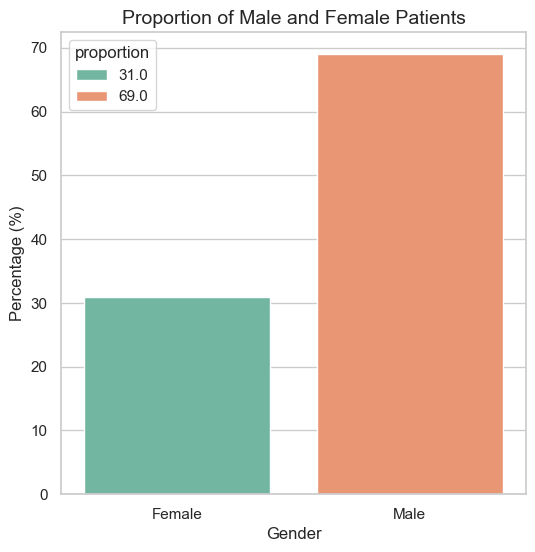

In [58]:
# Proportion of Male and Female Patients
plt.figure(figsize=(6, 6))
gender_counts = round(data['sex'].value_counts(normalize=True) * 100, 1)
sns.barplot(x=gender_counts.index, y=gender_counts.values, palette='Set2', hue=gender_counts)

# Set axis labels and plot title
plt.title('Proportion of Male and Female Patients', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.show()

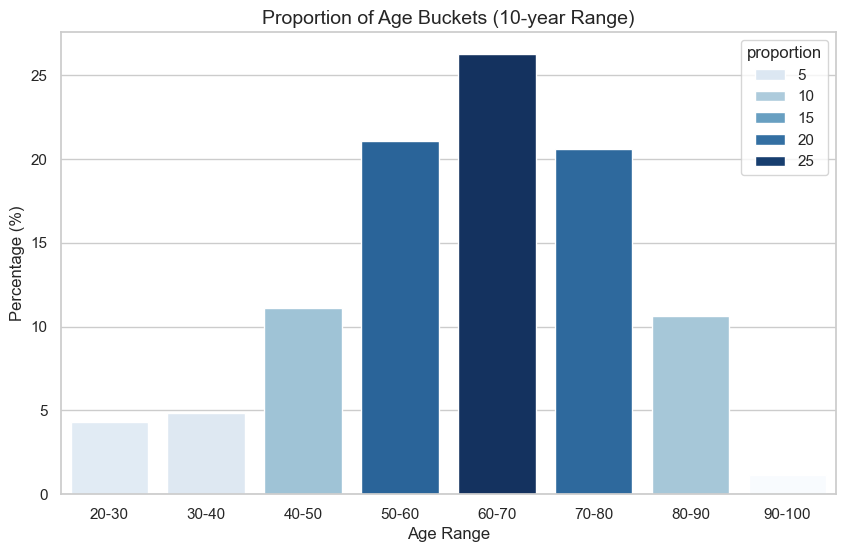

In [59]:
# Create age buckets (bins of 10 years)
data['age_bucket'] = pd.cut(data['age'], bins=range(20, 101, 10), right=False, labels=[f'{i}-{i+10}' for i in range(20, 100, 10)])

# Plot the distribution of age buckets
plt.figure(figsize=(10, 6))
age_bucket_counts = data['age_bucket'].value_counts(normalize=True).sort_index() * 100
sns.barplot(x=age_bucket_counts.index, y=age_bucket_counts.values, palette='Blues', hue=age_bucket_counts)

# Set axis labels and plot title
plt.title('Proportion of Age Buckets (10-year Range)', fontsize=14)
plt.xlabel('Age Range', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.show()

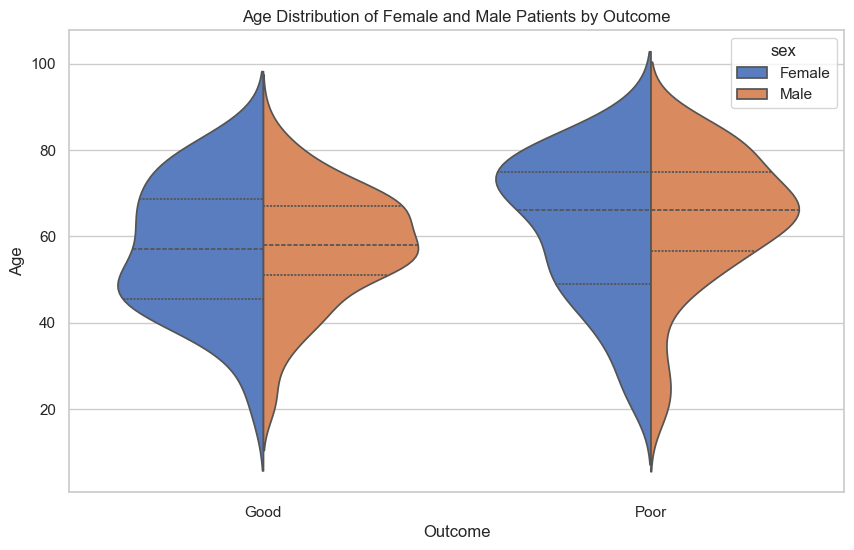

In [60]:
# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Create the violin plot showing age distribution, dividing by gender
sns.violinplot(data=data, y="age", x="outcome", hue="sex", split=True, inner="quart")

# Set axis labels and plot title
ax.set_title('Age Distribution of Female and Male Patients by Outcome')
ax.set_xlabel("Outcome")
ax.set_ylabel("Age")

# Show the plot
plt.show()


#### Analysis of Age Distribution of Female and Male Patients by Outcome

#### Graph 1: Proportion of Male and Female Patients
- The majority of patients are **male** (69.2%), while **female** patients make up 30.8% of the population.
- This imbalance in gender distribution is important to consider when analyzing outcomes, as gender may have an influence on recovery after cardiac arrest.

#### Graph 2: Proportion of Age Buckets (10-year Range)
- The most represented age group is **60-70 years** (around 25% of patients), followed by **50-60 years** and **70-80 years**.
- Fewer patients are in the younger age groups (20-30 and 30-40 years) and the very elderly (90-100 years).
- This distribution shows that the majority of cardiac arrest patients are in the **50-80 year range**, indicating that older adults are more likely to experience cardiac arrest.

#### Graph 3: Age Distribution of Female and Male Patients by Outcome
- The violin plot above shows the **age distribution** of male (orange) and female (blue) patients divided by their outcome (Good or Poor).
- **Good Outcome**: The age distribution for both male and female patients is relatively symmetrical, with a higher concentration of patients in the **50-70 years** range. Both genders have a similar shape, indicating similar age distributions for those with good outcomes.
- **Poor Outcome**: The distribution for poor outcomes shows a wider spread in age, particularly for older patients (around **60-80 years**). The distribution for male patients (orange) seems slightly more spread out, particularly in older age groups.

#### Key Insights:
- The **gender distribution** is heavily skewed towards males, with a much larger proportion of male patients compared to females.
- The age distribution highlights that older adults, particularly those between **60-70 years**, make up the largest proportion of the patient population.
- **Gender Comparison**: The plot uses **different colors** (blue for female and orange for male) to differentiate between the two genders, allowing for easy visual comparison of their age distributions within each outcome category.
- The age distribution is similar between genders for patients with good outcomes. However, in the poor outcome group, **female patients** tend to have a slightly wider spread in the older age range.
- Comparing distributions for good and poor outcome, it appears that poor outcome patients tend to be in an older age range than those with good outcomes.
- This analysis suggests that **age** plays a role in outcome prediction, and there may be subtle gender differences in the age distribution of patients who experience good vs. poor outcomes.

This demographic analysis provides a baseline understanding of the population, helping us see whether certain age or gender groups are more likely to have good or poor outcomes after cardiac arrest.

### 1. Analysis of the Distribution of Good and Bad Outcomes


Understanding the overall distribution of outcomes in the dataset is crucial for building context around recovery trends after cardiac arrest. By visualizing the **balance between good and bad outcomes**, we can assess how frequently patients recover well versus how often they experience poor outcomes. This can guide further analysis into the factors that contribute to each type of outcome. It is also important to understand the class imbalance of the target value.

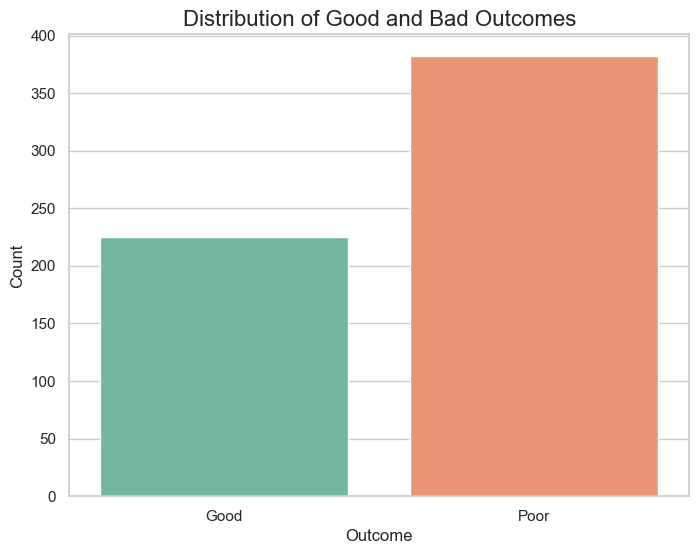

In [61]:
# Create a plot for the distribution of good and bad outcomes
plt.figure(figsize=(8, 6))
sns.countplot(x='outcome', data=data, palette='Set2', hue='outcome')

# Set the title and labels
plt.title('Distribution of Good and Bad Outcomes', fontsize=16)
plt.xlabel('Outcome', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Show the plot
plt.show()

### Analysis of Distribution of Good and Bad Outcomes

The bar chart above shows the **distribution of outcomes** across the patient population. The two categories represented are **Good** and **Poor outcomes**.

- The dataset shows a **significant imbalance** between good and poor outcomes, with nearly **twice as many patients** experiencing poor outcomes as compared to good ones.
- This suggests that the majority of patients in the dataset have **worse recovery trajectories**, which may be due to several clinical, demographic, or treatment-related factors.

#### Key Insights:
- **Good Outcomes**: Around 200 patients experienced a good outcome, indicating a recovery with minimal neurological damage or a favorable recovery from cardiac arrest.
- **Poor Outcomes**: Approximately 400 patients had a poor outcome, representing the majority of the patient population.


### 2. Feature Distribution Across the Dataset

This plot provides a comprehensive overview of the **distribution of all key features** in the dataset. It includes both **categorical** and **numerical** features, visualizing how frequently each category occurs or how the values of numerical features are spread across the patient population.

#### Purpose:
By showing the distribution of each feature, this graph helps us:
- Identify potential **imbalances** in the dataset (e.g., one category being overrepresented).
- Observe the **range of numerical variables** and check for any **skewness** or **outliers**.
- Ensure the dataset is clean and ready for more detailed analysis by spotting any **unexpected patterns** in the features.


C:\Users\kentf\AppData\Local\Temp\ipykernel_14492\2622581578.py:24: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.countplot(data=data, x=column, ax=axes[i], hue=column, palette=[
C:\Users\kentf\AppData\Local\Temp\ipykernel_14492\2622581578.py:24: UserWarning: 
The palette list has fewer values (4) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=data, x=column, ax=axes[i], hue=column, palette=[
C:\Users\kentf\AppData\Local\Temp\ipykernel_14492\2622581578.py:24: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.countplot(data=data, x=column, ax=axes[i], hue=column, palette=[
C:\Users\kentf\AppData\Local\Temp\ipykernel_14492\2622581578.py:24: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.countplot(data=data, x=column, ax=axes[i], hue=column, palette=[
C:\Users\kentf\AppData\Local\Temp\i

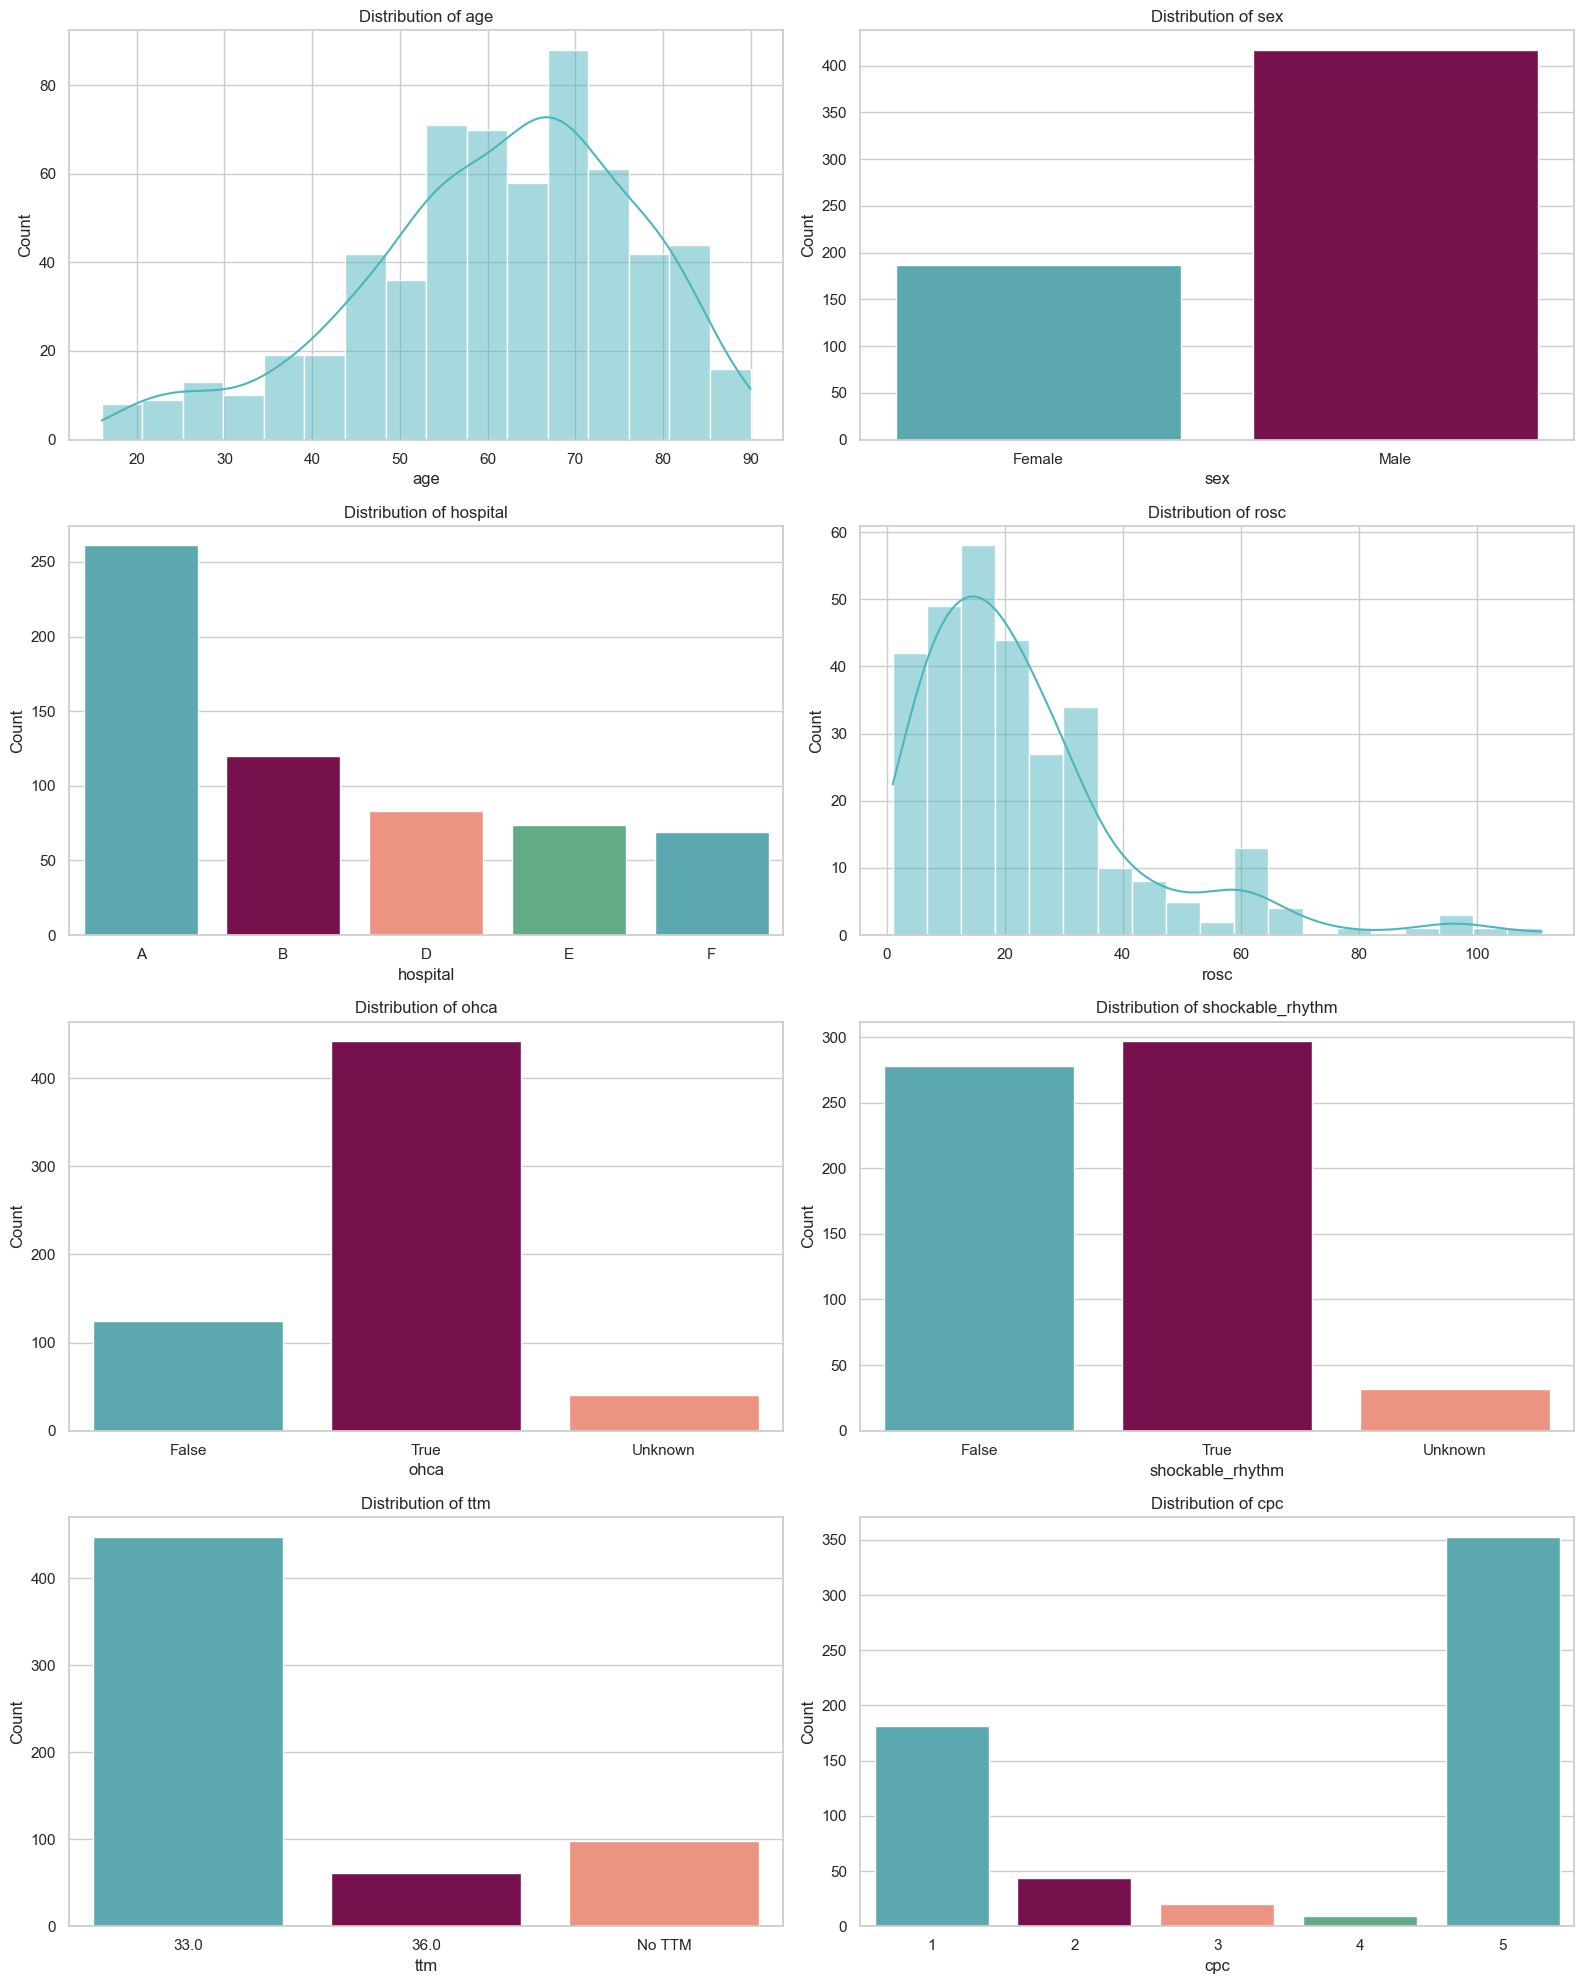

In [62]:
# List of all relevant features (you can modify this list)
columns_to_plot = ['age', 'sex', 'hospital', 'rosc', 'ohca', 'shockable_rhythm', 'ttm', 'cpc']

# Karolinska Institutet Colors
KI_COLORS = {
    "skyblue": "#4DB5BC",
    "lightorange": "#FFDDD6",
    "orange": "#FF876F",
    "plum": "#870052",
    "grey": "#666666",
    "green": "#54B986",
    "yellow": "#FFC66D",
    "darkplum": "#4F0433"
}

# Set up the facet grid for multiple smaller graphs
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 20))
axes = axes.flatten()  # Flatten the grid for easier indexing

# Loop over the columns and create a plot for each feature
for i, column in enumerate(columns_to_plot):
    if isinstance(data[column].dtype, pd.CategoricalDtype) or data[column].dtype == object:
        # For categorical features
        sns.countplot(data=data, x=column, ax=axes[i], hue=column, palette=[
            KI_COLORS['skyblue'], KI_COLORS['plum'], KI_COLORS['orange'], KI_COLORS['green']
        ], legend=False)
    else:
        # For numerical features
        sns.histplot(data=data, x=column, ax=axes[i], kde=True, color=KI_COLORS['skyblue'])

    # Set the title for each plot
    axes[i].set_title(f'Distribution of {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Count')

# Adjust layout to prevent overlapping
plt.tight_layout()


# Save and Show
plt.savefig('graphics/eda_distributions_transparent.svg', format='svg', transparent=True)  # Set transparent=True
plt.savefig('graphics/eda_distributions_white.svg', format='svg', transparent=False)
plt.show()

### 3. Feature Distribution Overview for Good and Bad Outcomes

#### What is being done:
To understand which patient features are associated with **good** and **bad outcomes**, we visualize the distribution of various features for both outcome groups. The dataset has been filtered to include only patients with either **good** or **poor outcomes**, and we generate plots for each feature to compare the two groups side by side.

#### Steps:
- **Data Filtering**: We filter the data to only include patients with **Good** or **Poor** outcomes.
- **Feature Selection**: The following features are selected for visualization: `age`, `sex`, `hospital`, `rosc`, `ohca`, `shockable_rhythm`, `ttm`, and `cpc`.
- **Plotting**: 
  - **Categorical features** (e.g., `sex`, `hospital`, `shockable_rhythm`, `ttm`) are visualized using **count plots** to show the number of patients in each category for both outcomes.
  - **Numerical features** (e.g., `age`, `rosc`) are visualized using **histograms** with **Kernel Density Estimate (KDE)** curves to display their distributions for each outcome group.
- **Color Coding**: Different colors are used to distinguish between **good** and **poor outcomes**, allowing us to compare the distribution of each feature for the two groups.

#### Purpose:
This visualization helps us explore the key characteristics that differentiate patients with good outcomes from those with poor outcomes. By analyzing the distribution of each feature, we can gain insights into how demographic and clinical factors are associated with recovery after cardiac arrest.


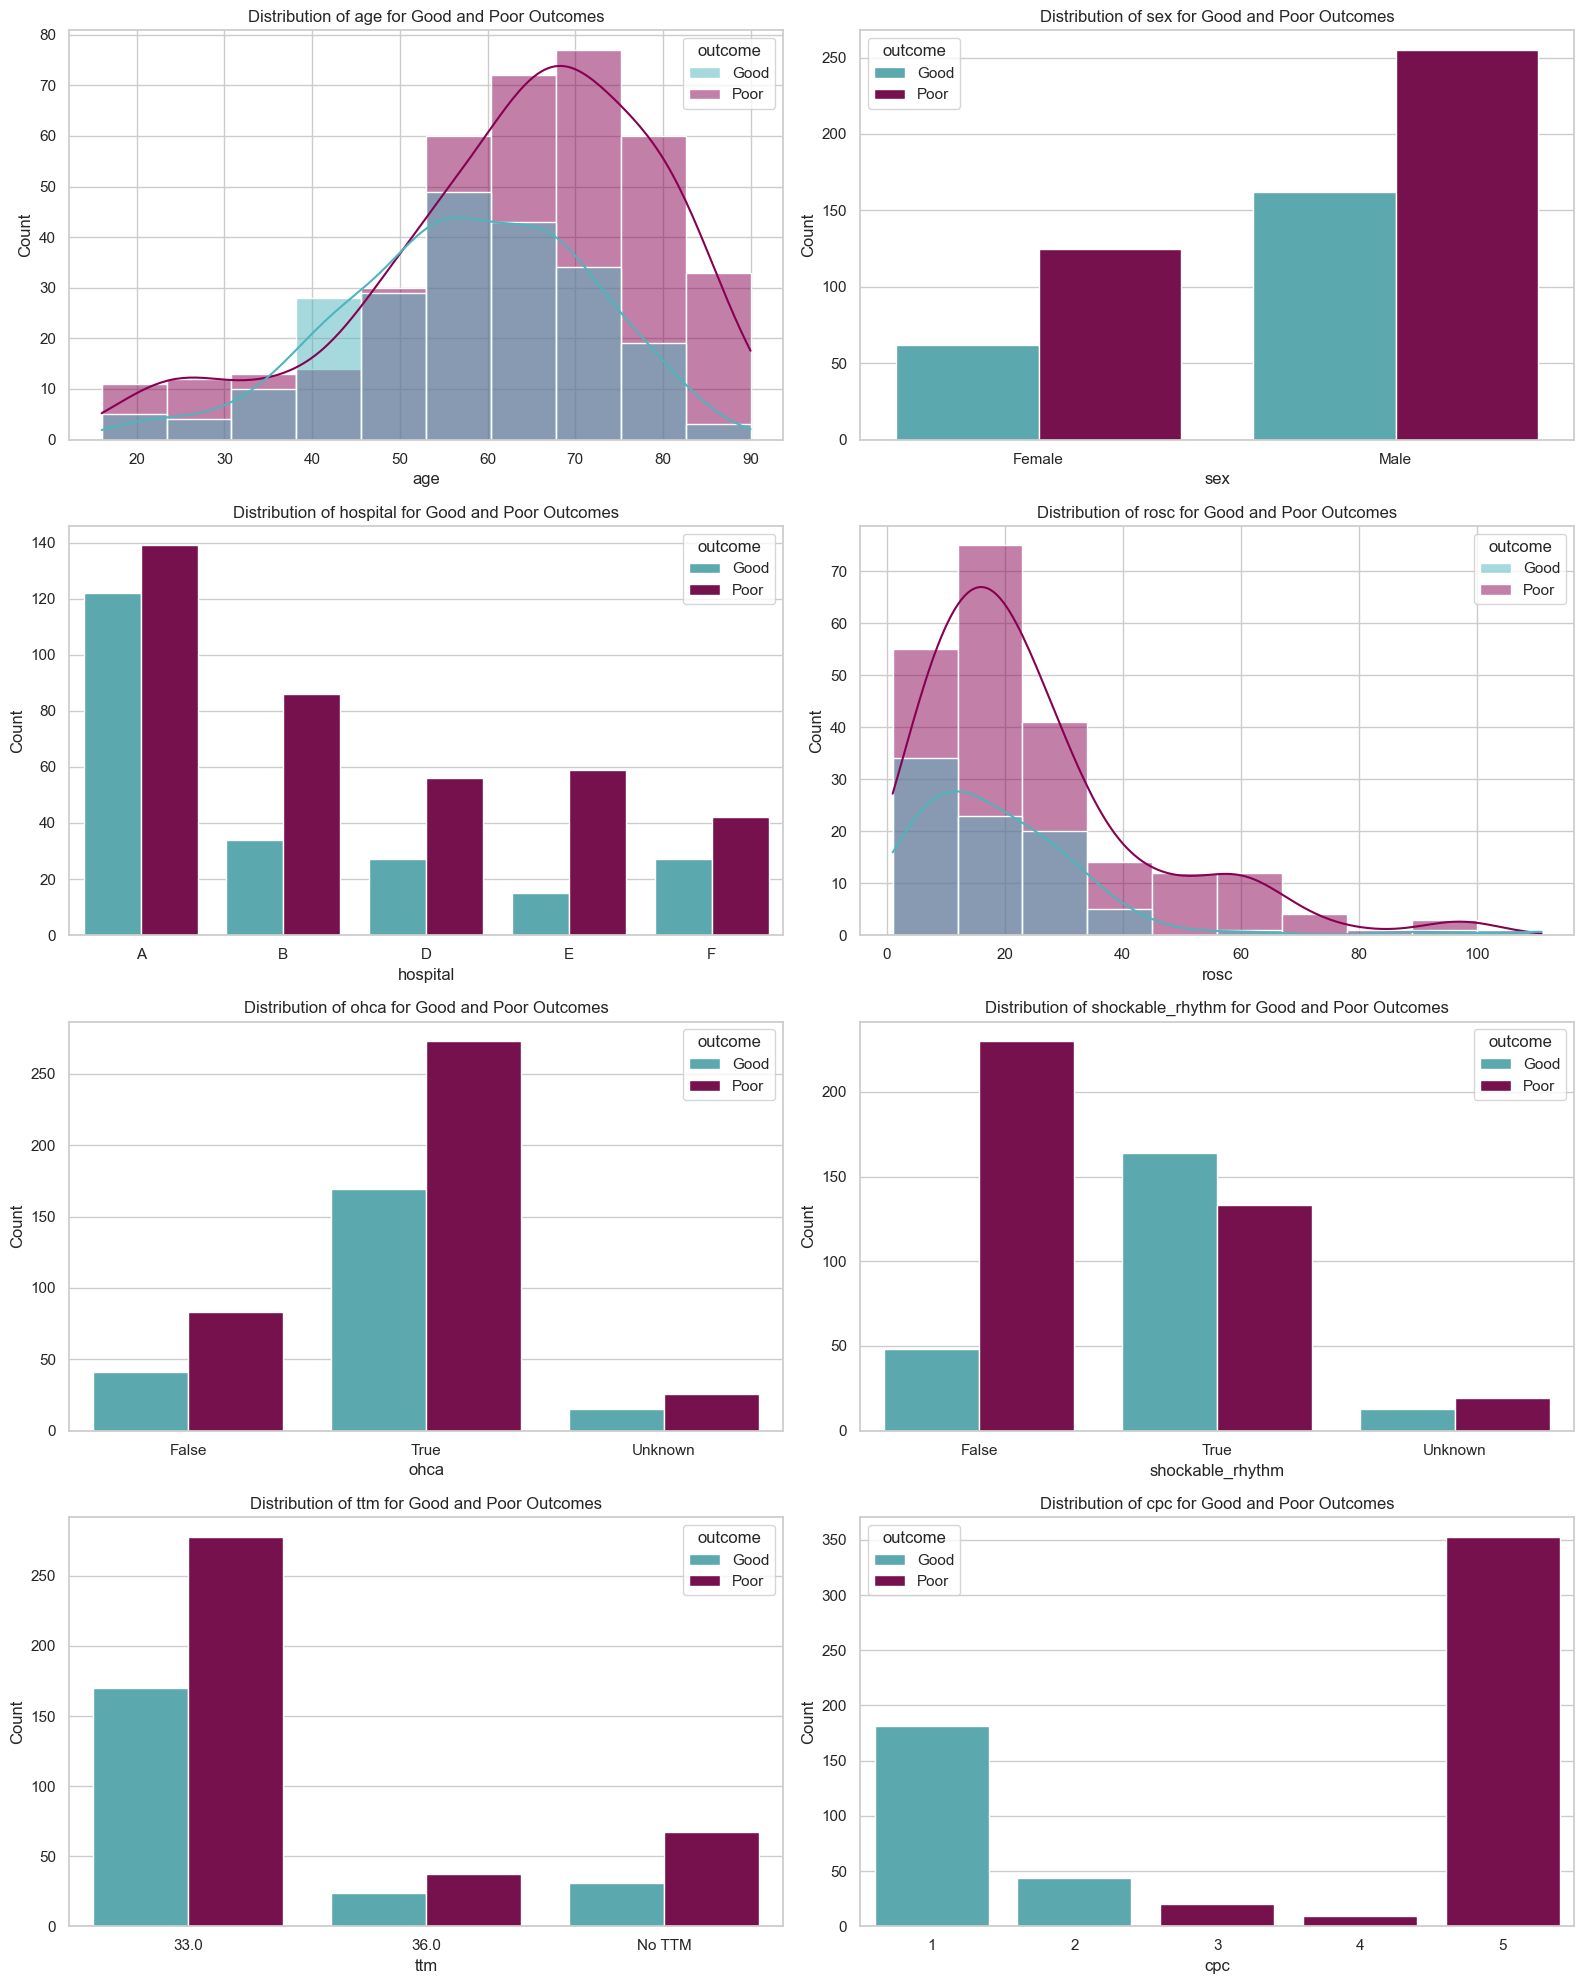

In [63]:
# Create a filtered dataset for good and bad outcomes
outcome_data = data[data['outcome'].isin(['Good', 'Poor'])]

# Select the relevant columns for visualization (numerical and categorical)
columns_to_plot = ['age', 'sex', 'hospital', 'rosc', 'ohca', 'shockable_rhythm', 'ttm', 'cpc']

# Karolinska Institutet Colors for outcomes
KI_COLORS = {
    "good_outcome": "#4DB5BC",  # Blueish for Good
    "bad_outcome": "#870052"    # Purple for Poor
}

# Set up the facet grid for multiple smaller graphs
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 20))
axes = axes.flatten()  # Flatten the grid for easier indexing

# Loop over the columns and create a plot for each feature
for i, column in enumerate(columns_to_plot):
    if isinstance(data[column].dtype, pd.CategoricalDtype) or data[column].dtype == object:
        # For categorical features
        sns.countplot(
            data=outcome_data, 
            x=column, 
            hue='outcome', 
            ax=axes[i], 
            palette=[KI_COLORS['good_outcome'], KI_COLORS['bad_outcome']]
        )
    else:  
        # For numerical features
        sns.histplot(
            data=outcome_data, 
            x=column, 
            hue='outcome', 
            ax=axes[i], 
            bins=10, 
            kde=True, 
            palette=[KI_COLORS['good_outcome'], KI_COLORS['bad_outcome']]
        )

    # Set the title for each plot
    axes[i].set_title(f'Distribution of {column} for Good and Poor Outcomes')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Count')

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()


### 4. What is the distribution of age among patients, and does it vary by outcome?


Understanding the distribution of age in more detail in our patient population is important as age can be a critical factor in determining survival and recovery outcomes after cardiac arrest. By exploring this, we can gain insights into whether age impacts the likelihood of achieving a good or poor outcome. This will help us assess the role age plays in post-resuscitation care.

In this analysis, we will plot the distribution of age for all patients and then examine the distribution based on the neurological outcome (good vs. poor outcome).


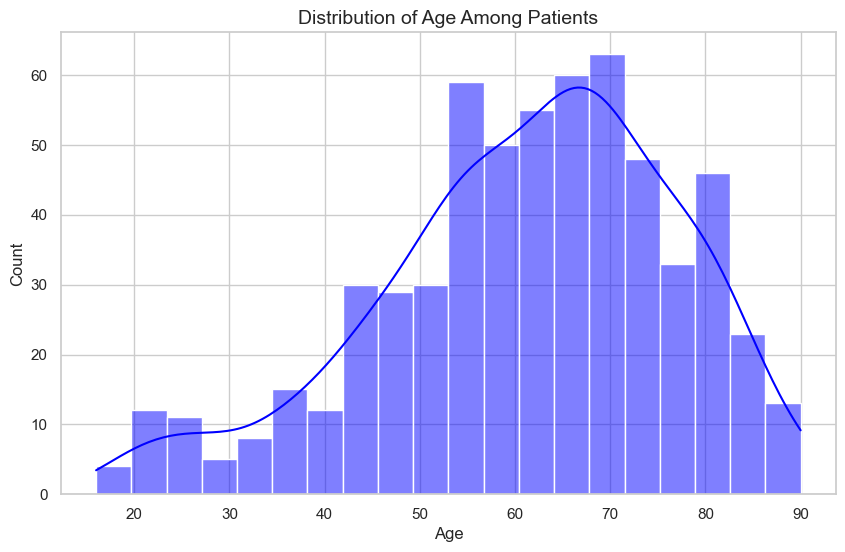

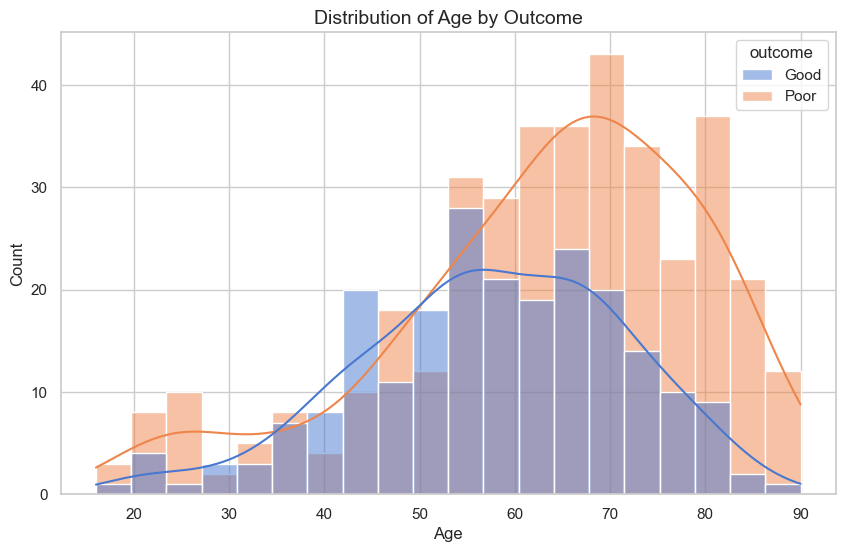

In [64]:
# Plot the distribution of age overall
plt.figure(figsize=(10, 6))
sns.histplot(data['age'], bins=20, kde=True, color='blue')
plt.title('Distribution of Age Among Patients', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

# Plot the distribution of age by outcome
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='age', hue='outcome', bins=20, kde=True)
plt.title('Distribution of Age by Outcome', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

### Analysis of Age Distribution

#### Graph 1: Overall Age Distribution
- The distribution of age is approximately **normal**, peaking around **60–70 years old**.
- Most patients fall between **50 and 80 years old**, with fewer in the younger (below 30) and older (above 80) age ranges.

#### Graph 2: Age Distribution by Outcome (Good vs Poor)
- **Good outcome** (blue): Peaks around **50-60 years old**; very few good outcomes in patients above 70.
- **Poor outcome** (orange): Peaks around **70-80 years old**; older patients tend to have worse outcomes.
- Younger patients (<60) are more likely to have a **good outcome**, while older patients (>70) tend to have a **poor outcome**.

#### Key Insights:
- **Age is a significant predictor** of outcome: Younger patients are more likely to recover well, while older patients are more prone to poor outcomes.


### 5. Is there a relationship between ROSC (return of spontaneous circulation) time and patient outcome?


Time until ROSC is a critical factor in the recovery process after cardiac arrest. A longer ROSC time may indicate delayed resuscitation, or longer resuscitation with more epiephrin give, which could negatively impact the patient's outcome. By analyzing the relationship between ROSC time and neurological outcomes, we can better understand whether quicker return of circulation correlates with better recovery. 

This analysis will help us identify any trends between ROSC time and outcome categories.


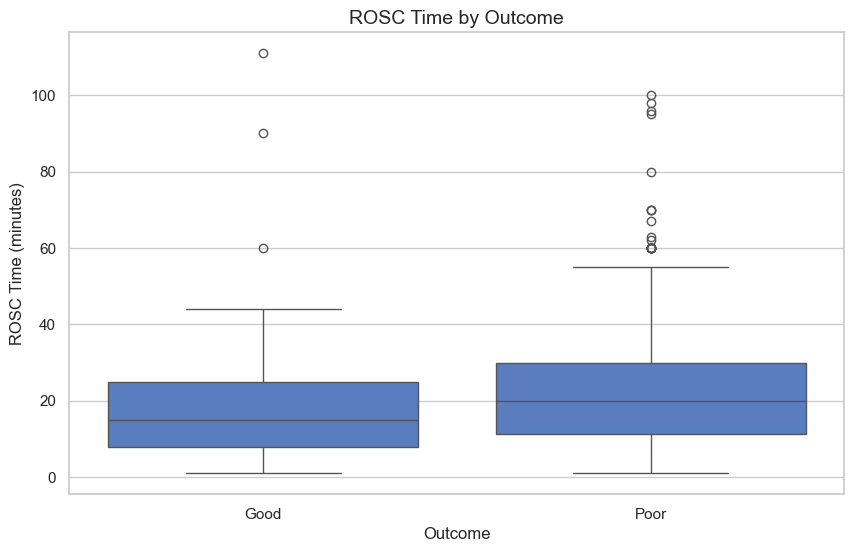

Median ROSC time by outcome (excluding -1 placeholder):
outcome
Good    15.0
Poor    20.0
Name: rosc, dtype: float64


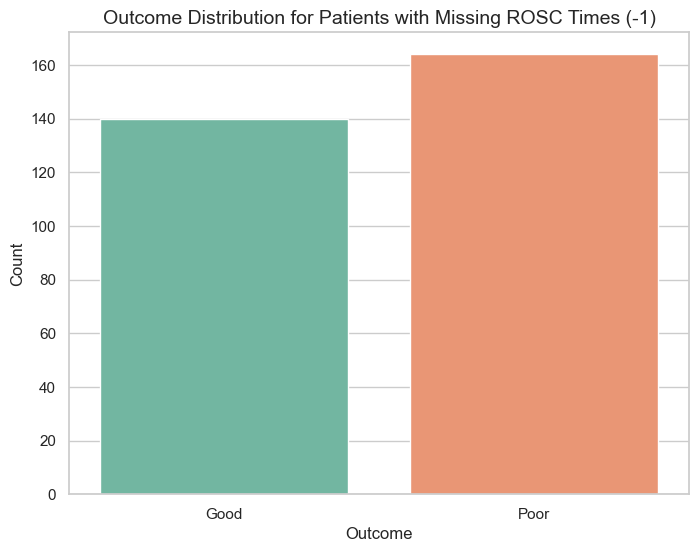

Percentage distribution of outcomes for patients with missing ROSC times (-1):
outcome
Poor    53.947368
Good    46.052632
Name: proportion, dtype: float64


In [65]:
# Exclude ROSC placeholder (-1) values from the data
valid_data = data[data['rosc'] != -1]

# Box plot for ROSC time vs outcome using only valid ROSC data
plt.figure(figsize=(10, 6))
sns.boxplot(x='outcome', y='rosc', data=valid_data)
plt.title('ROSC Time by Outcome', fontsize=14)
plt.xlabel('Outcome', fontsize=12)
plt.ylabel('ROSC Time (minutes)', fontsize=12)
plt.show()

# Calculate the median ROSC time for each outcome category, excluding -1
rosc_medians_cleaned = valid_data.groupby('outcome', observed=False)['rosc'].median()
print("Median ROSC time by outcome (excluding -1 placeholder):")
print(rosc_medians_cleaned)

# Filter out data where ROSC is missing (np.nan values)
missing_rosc_data = data[data['rosc'].isna()]

# Bar plot for the outcome distribution of patients with missing ROSC times (-1)
plt.figure(figsize=(8, 6))
sns.countplot(x='outcome', data=missing_rosc_data, palette='Set2', hue="outcome")
plt.title('Outcome Distribution for Patients with Missing ROSC Times (-1)', fontsize=14)
plt.xlabel('Outcome', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

# Calculate the percentage of outcomes for patients with missing ROSC times (-1)
outcome_distribution_missing_rosc = missing_rosc_data['outcome'].value_counts(normalize=True) * 100
print("Percentage distribution of outcomes for patients with missing ROSC times (-1):")
print(outcome_distribution_missing_rosc)

### Analysis of ROSC Time and Outcome

#### Graph 1: ROSC Time by Outcome (Excluding -1)
- **Good Outcome**: The median ROSC time is **15 minutes**.
- **Poor Outcome**: The median ROSC time is **20 minutes**, and the overall spread is larger.
- **Key Insight**: Patients with poor outcomes tend to have a slightly longer ROSC time. The difference between good and poor outcomes is not drastic, but a higher ROSC time is associated with a poorer outcome.

#### Graph 2: Outcome Distribution for Patients with Missing ROSC Times (-1)
- **Poor Outcome**: **53.95%** of patients with missing ROSC times had poor outcomes.
- **Good Outcome**: **46.05%** had good outcomes.
- **Key Insight**: The distribution is relatively balanced, but more patients with missing ROSC times tend to have poor outcomes. Missing ROSC values might still carry important clinical significance.

These results highlight the importance of ROSC time and suggest that missing ROSC data may be linked to a slightly higher chance of poor outcomes. However, the difference in outcomes for those with missing ROSC data is not extreme, suggesting other factors may also be influencing the results.


### 6. How does the application of TTM (Targeted Temperature Management) vary across patient outcomes?


TTM is a key therapeutic intervention in post-cardiac arrest care. By analyzing how different TTM levels (33 Degree, 36 Degree, or No TTM) are applied across patient outcomes, we can assess whether certain temperature management strategies are associated with better recovery. This can give us insight into the effectiveness of TTM in different patient subgroups and contribute to understanding optimal care strategies.


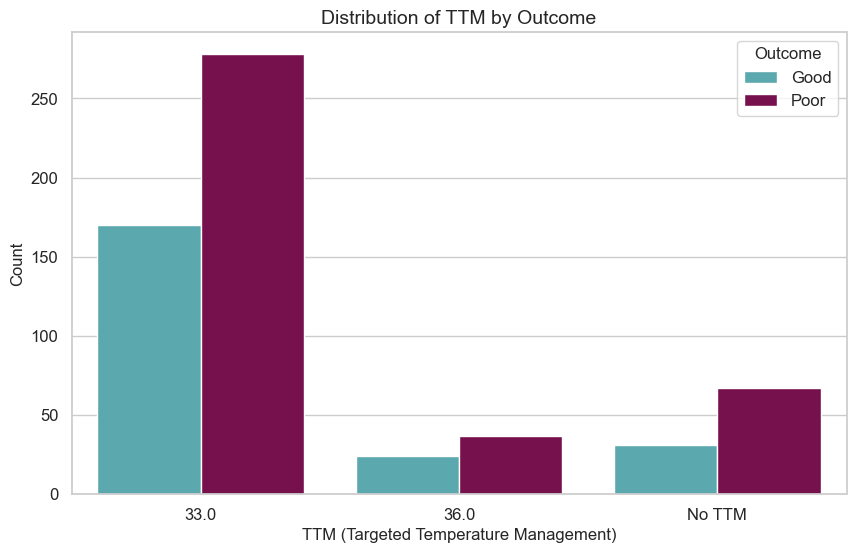

Percentage distribution of outcomes within each TTM category:
outcome       Good       Poor
ttm                          
33.0     37.946429  62.053571
36.0     39.344262  60.655738
No TTM   31.632653  68.367347


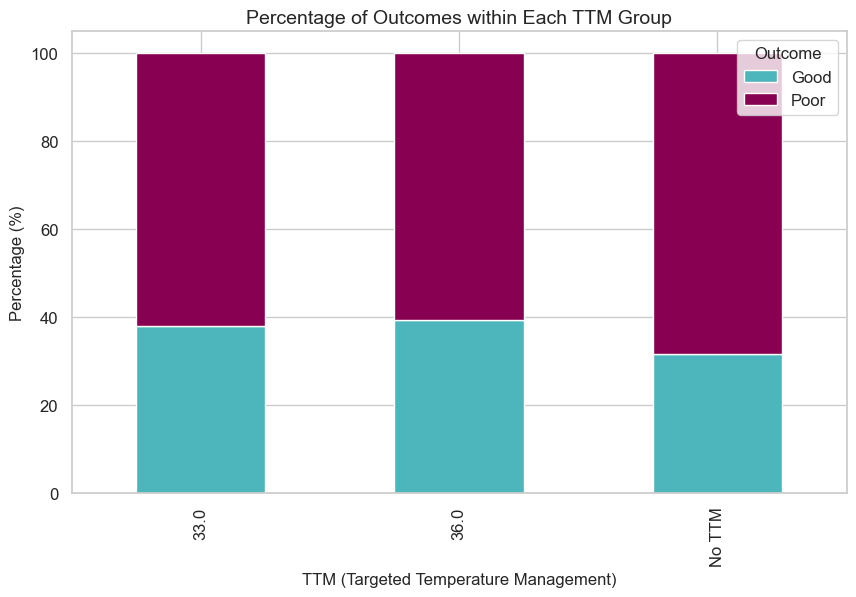

In [66]:
# Define Karolinska Institutet colors for Good and Poor outcomes
KI_COLORS = {
    "good_outcome": "#4DB5BC",  # Blueish for Good
    "bad_outcome": "#870052"    # Purple for Poor
}

# Bar plot for TTM application by outcome
plt.figure(figsize=(10, 6))
sns.countplot(
    x='ttm', 
    hue='outcome', 
    data=data, 
    palette=[KI_COLORS['good_outcome'], KI_COLORS['bad_outcome']]
)
plt.title('Distribution of TTM by Outcome', fontsize=14)
plt.xlabel('TTM (Targeted Temperature Management)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Outcome', fontsize=12, loc='upper right')

# Save and Show
plt.savefig('graphics/eda_ttm_outcome_distribution_transparent.svg', format='svg', transparent=True)  # Set transparent=True
plt.savefig('graphics/eda_ttm_outcome_distribution_white.svg', format='svg', transparent=False)

plt.show()

# Percentage of TTM usage by outcome within each TTM group
ttm_outcome_distribution = data.groupby('ttm', observed=False)['outcome'].value_counts(normalize=True).unstack()

# Convert to percentages and display
ttm_outcome_distribution = ttm_outcome_distribution * 100
print("Percentage distribution of outcomes within each TTM category:")
print(ttm_outcome_distribution)

# Visualizing the percentage distribution as a stacked bar plot
ttm_outcome_distribution.plot(
    kind='bar', 
    stacked=True, 
    figsize=(10, 6), 
    color=[KI_COLORS['good_outcome'], KI_COLORS['bad_outcome']]
)
plt.title('Percentage of Outcomes within Each TTM Group', fontsize=14)
plt.xlabel('TTM (Targeted Temperature Management)', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Outcome', fontsize=12, loc='upper right')
# Save and Show
plt.savefig('graphics/eda_ttm_outcome_distribution_rel_transparent.svg', format='svg', transparent=True)  # Set transparent=True
plt.savefig('graphics/eda_ttm_outcome_distribution_rel_white.svg', format='svg', transparent=False)

plt.show()


### Analysis of TTM (Targeted Temperature Management) by Outcome

#### Graph 1: Distribution of TTM by Outcome
- **33 Degree TTM**: The largest group, with more patients having a **poor outcome** (62.05%) compared to a **good outcome** (37.95%).
- **36 Degree TTM**: Similar pattern, but with a slightly higher proportion of good outcomes (39.34% good vs. 60.66% poor).
- **No TTM**: Has the highest proportion of poor outcomes (68.37%) compared to 31.63% good outcomes.

#### Graph 2: Percentage of Outcomes within Each TTM Group
- The proportion of **poor outcomes** is higher across all groups, with **No TTM** showing the highest percentage of poor outcomes.
- **33 Degree TTM** and **36 Degree TTM** have slightly better outcomes compared to No TTM, but still a majority of patients in these groups have poor outcomes.

#### Key Insight:
- **TTM at 33 and 36 Degrees**: Both seem to result in similar outcome distributions, with **33 Degree TTM** showing slightly worse outcomes than **36 Degree TTM**.
- **No TTM**: Patients who did not receive TTM have the worst outcomes, suggesting that the absence of TTM may be associated with poorer recovery.


### 7. Does the presence of a shockable rhythm affect the patient’s outcome?


The type of rhythm at the time of cardiac arrest (shockable vs non-shockable) plays a critical role in resuscitation success. Shockable rhythms (such as ventricular fibrillation) are often associated with better survival outcomes if treated early. This analysis explores whether patients presenting with a shockable rhythm have a higher likelihood of a good outcome.


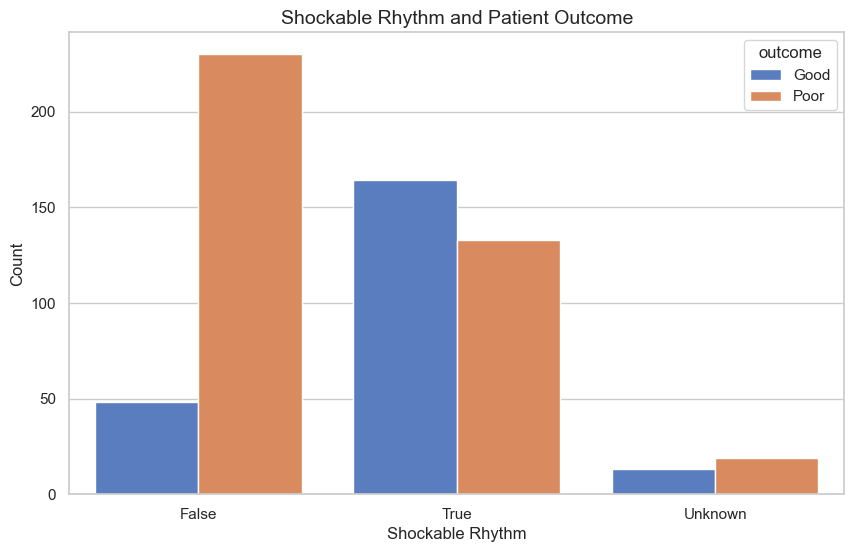

Percentage distribution of outcome by Shockable Rhythm:
outcome               Good      Poor
shockable_rhythm                    
False             0.172662  0.827338
True              0.552189  0.447811
Unknown           0.406250  0.593750


C:\Users\kentf\AppData\Local\Temp\ipykernel_14492\3510899676.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  shockable_rhythm_outcome = data.groupby('shockable_rhythm')['outcome'].value_counts(normalize=True).unstack()


In [67]:
# Bar plot for Shockable Rhythm vs Outcome
plt.figure(figsize=(10, 6))
sns.countplot(x='shockable_rhythm', hue='outcome', data=data)
plt.title('Shockable Rhythm and Patient Outcome', fontsize=14)
plt.xlabel('Shockable Rhythm', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

# Calculate percentage of outcomes for each rhythm type
shockable_rhythm_outcome = data.groupby('shockable_rhythm')['outcome'].value_counts(normalize=True).unstack()
print("Percentage distribution of outcome by Shockable Rhythm:")
print(shockable_rhythm_outcome)

### Analysis of Shockable Rhythm and Patient Outcome

#### Graph: Shockable Rhythm and Patient Outcome
- **False (Non-shockable Rhythm)**: A large majority of patients (82.73%) with non-shockable rhythms had poor outcomes, while only 17.27% had good outcomes.
- **True (Shockable Rhythm)**: A significantly better distribution, with 55.22% of patients having good outcomes and 44.78% having poor outcomes. This suggests that patients with shockable rhythms have a higher chance of recovery.
- **Unknown**: The outcomes are more balanced, with 40.63% having good outcomes and 59.38% poor outcomes. This could indicate that there is a mix of patients with and without shockable rhythms, more without shockable rhythm.

#### Key Insights:
- **Shockable Rhythms**: Patients with shockable rhythms are much more likely to have **good outcomes** compared to those with non-shockable rhythms.
- **Non-shockable Rhythms**: These rhythms are associated with a significantly higher proportion of poor outcomes.
- **Unknown Data**: The "Unknown" category shows a relatively even distribution but leans towards poorer outcomes.

Overall, the presence of a shockable rhythm appears to be a critical factor in improving outcomes after cardiac arrest.


### 8. What is the distribution of Cerebral Performance Category (CPC) scores in the patient population?


The CPC score is a key measure of neurological function after cardiac arrest, ranging from good function (CPC 1) to death (CPC 5). By analyzing the distribution of CPC scores, we can gain a better understanding of the general outcomes in this population, and whether certain patient characteristics are associated with better or worse neurological recovery. This analysis helps identify patterns in neurological function post-resuscitation.


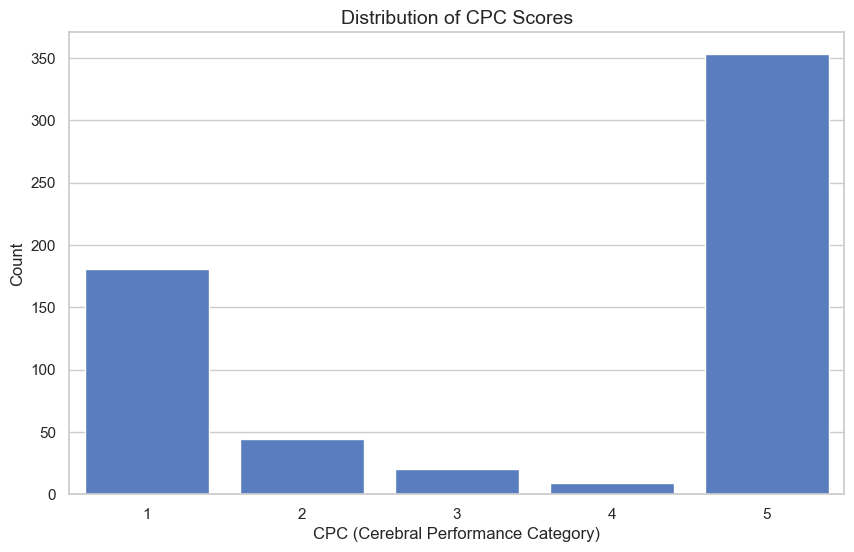

In [68]:
# Bar plot for CPC distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='cpc', data=data)
plt.title('Distribution of CPC Scores', fontsize=14)
plt.xlabel('CPC (Cerebral Performance Category)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()


### Analysis of CPC (Cerebral Performance Category) Scores

#### Graph: Distribution of CPC Scores
- **CPC 1 (Good neurological function)**: A significant portion of patients fall into this category, indicating a good neurological outcome for over **150 patients**.
- **CPC 2 (Moderate disability)**: Fewer patients are in this group, with only a small fraction having moderate neurological disability.
- **CPC 3 (Severe disability)** and **CPC 4 (Unresponsive wakefulness)**: Very few patients fall into these categories, indicating that a small number of patients have severe neurological damage or unresponsive states.
- **CPC 5 (Death)**: The majority of patients are in this category, with over **350 patients** recorded as deceased.

#### Key Insights:
- **Good outcomes** (CPC 1 and 2) are much less frequent compared to **poor outcomes** (CPC 3, 4, 5), especially in the CPC 5 category (death).
- The distribution highlights that a large proportion of patients either survive with **good neurological function** or do not survive at all, with fewer in-between outcomes such as moderate or severe disability.

These insights show a stark division in outcomes, with many patients either making a good recovery or passing away, and relatively few experiencing moderate to severe neurological disability.


### 9. What is the relationship between ROSC time and Out-of-hospital cardiac arrest?

ROSC (Return of Spontaneous Circulation) time is a critical factor in assessing the outcomes of cardiac arrest patients, as it reflects the duration taken to restore circulation. This time can vary significantly depending on the location of the cardiac arrest—whether it occurred in-hospital or out-of-hospital. **Out-of-hospital cardiac arrest (OHCA)** often involves longer response times, which can impact ROSC time and subsequently influence patient outcomes.

By analyzing the relationship between ROSC time and OHCA, we aim to understand how different environments (in-hospital vs. out-of-hospital) affect the recovery time for circulation and the subsequent prognosis. This analysis can reveal:
- **Differences in ROSC times** between in-hospital and out-of-hospital settings.
- **Impact of ROSC time on patient outcomes**, such as neurological recovery and survival, particularly in the context of delayed interventions common in OHCA situations.
- **Factors influencing ROSC times** in OHCA, such as response time, emergency medical intervention quality, and availability of bystander CPR.

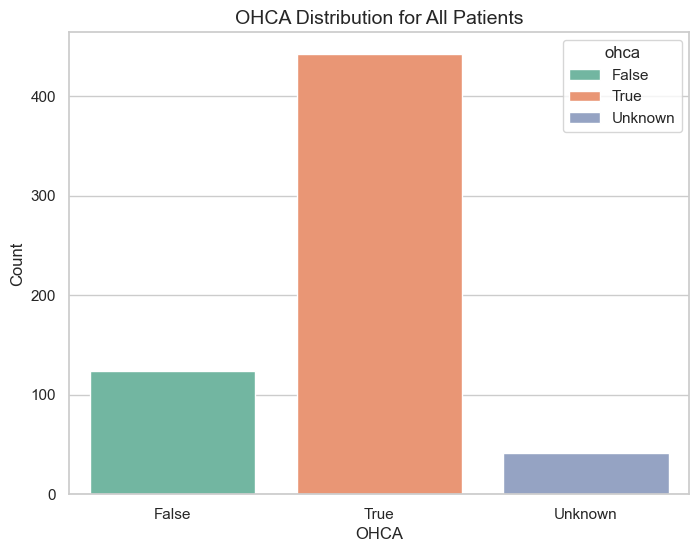

Number of observations per OHCA category (all patients):
ohca
True       442
False      124
Unknown     41
Name: count, dtype: int64

Percentage of observations per OHCA category (all patients):
ohca
True       72.817133
False      20.428336
Unknown     6.754530
Name: proportion, dtype: float64


In [69]:
# Bar plot for the OHCA distribution of all patients
plt.figure(figsize=(8, 6))
sns.countplot(x='ohca', data=data, palette='Set2', hue='ohca')
plt.title('OHCA Distribution for All Patients', fontsize=14)
plt.xlabel('OHCA', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

# Print the number of observations and percentages per OHCA category (all patients)
all_ohca_count = data['ohca'].value_counts()
all_ohca_percentage = data['ohca'].value_counts(normalize=True) * 100

print("Number of observations per OHCA category (all patients):")
print(all_ohca_count)
print("\nPercentage of observations per OHCA category (all patients):")
print(all_ohca_percentage)


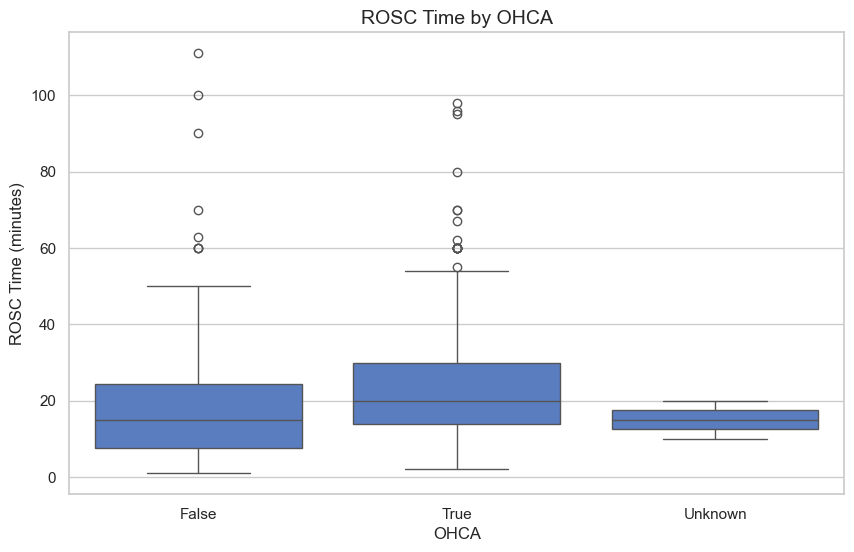

Median ROSC time by OHCA (excluding missing values):
ohca
False      15.0
True       20.0
Unknown    15.0
Name: rosc, dtype: float64

Number of observations per OHCA category (valid ROSC values):
ohca
True       205
False       95
Unknown      3
Name: count, dtype: int64


C:\Users\kentf\AppData\Local\Temp\ipykernel_14492\1748108721.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rosc_medians_cleaned = valid_data.groupby('ohca')['rosc'].median()


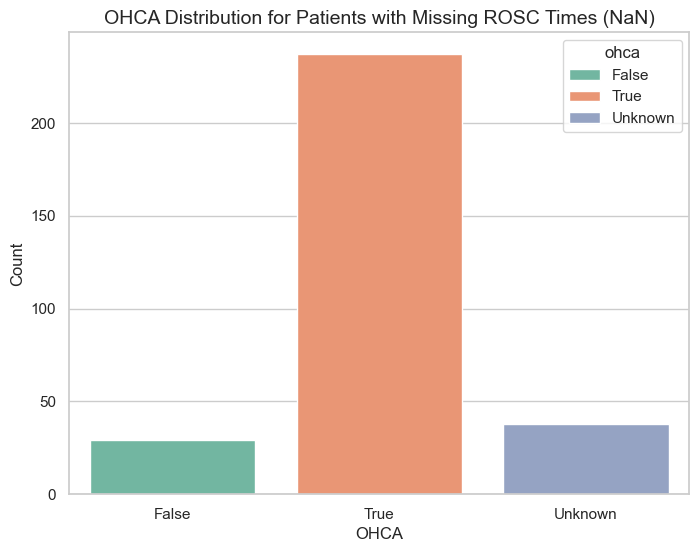


Percentage distribution of OHCA categories for patients with missing ROSC times (NaN):
ohca
True       77.960526
Unknown    12.500000
False       9.539474
Name: proportion, dtype: float64

Number of observations per OHCA category (missing ROSC values):
ohca
True       237
Unknown     38
False       29
Name: count, dtype: int64


In [70]:
# Exclude rows where ROSC is missing (np.nan values)
valid_data = data[data['rosc'].notna()]

# Box plot for ROSC time vs OHCA using only valid ROSC data
plt.figure(figsize=(10, 6))
sns.boxplot(x='ohca', y='rosc', data=valid_data)
plt.title('ROSC Time by OHCA', fontsize=14)
plt.xlabel('OHCA', fontsize=12)
plt.ylabel('ROSC Time (minutes)', fontsize=12)
plt.show()

# Calculate the median ROSC time for each OHCA category, excluding missing values
rosc_medians_cleaned = valid_data.groupby('ohca')['rosc'].median()
print("Median ROSC time by OHCA (excluding missing values):")
print(rosc_medians_cleaned)

# Print the number of observations per OHCA category (valid ROSC)
valid_rosc_count = valid_data['ohca'].value_counts()
print("\nNumber of observations per OHCA category (valid ROSC values):")
print(valid_rosc_count)

# Filter out data where ROSC is missing (np.nan values)
missing_rosc_data = data[data['rosc'].isna()]

# Bar plot for the OHCA distribution of patients with missing ROSC times (NaN)
plt.figure(figsize=(8, 6))
sns.countplot(x='ohca', data=missing_rosc_data, palette='Set2', hue="ohca")
plt.title('OHCA Distribution for Patients with Missing ROSC Times (NaN)', fontsize=14)
plt.xlabel('OHCA', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

# Calculate the percentage of OHCA categories for patients with missing ROSC times (NaN)
ohca_distribution_missing_rosc = missing_rosc_data['ohca'].value_counts(normalize=True) * 100
print("\nPercentage distribution of OHCA categories for patients with missing ROSC times (NaN):")
print(ohca_distribution_missing_rosc)

# Print the number of observations per OHCA category (missing ROSC)
missing_rosc_count = missing_rosc_data['ohca'].value_counts()
print("\nNumber of observations per OHCA category (missing ROSC values):")
print(missing_rosc_count)


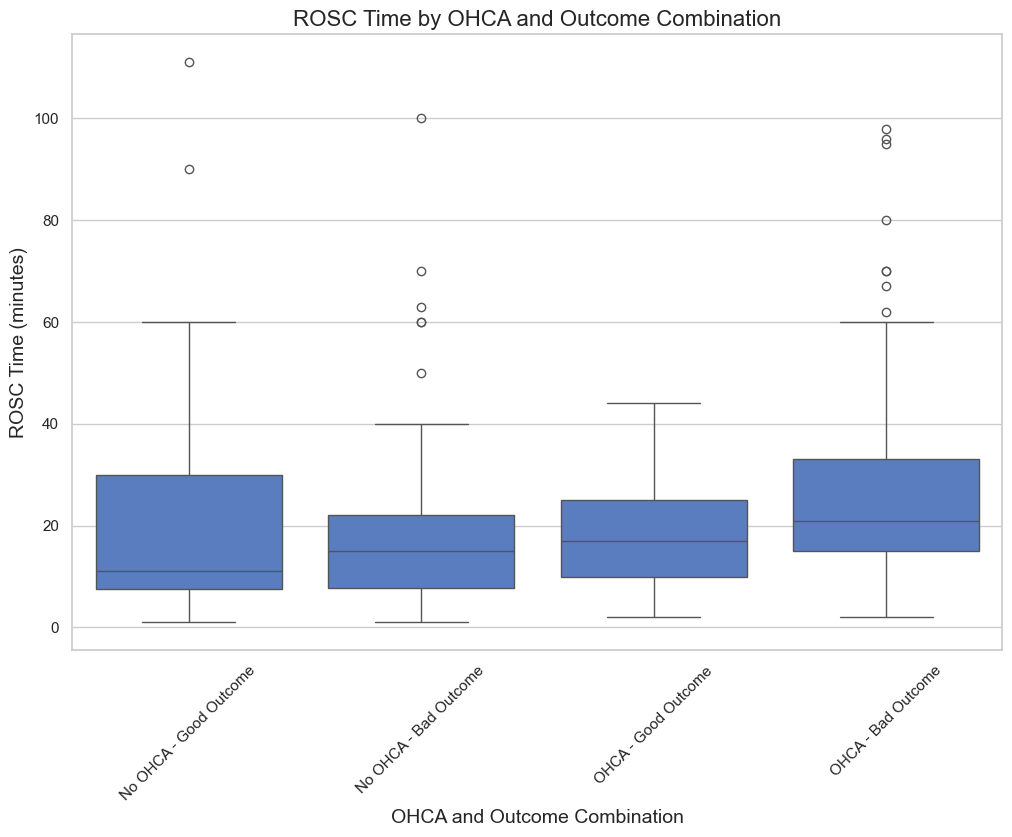

Median ROSC time by OHCA and Outcome Combination (excluding missing values):
ohca_outcome
No OHCA - Bad Outcome     15.0
No OHCA - Good Outcome    11.0
OHCA - Bad Outcome        21.0
OHCA - Good Outcome       17.0
Name: rosc, dtype: float64

Number of observations per OHCA and Outcome Combination (valid ROSC values):
ohca_outcome
OHCA - Bad Outcome        154
No OHCA - Bad Outcome      64
OHCA - Good Outcome        54
No OHCA - Good Outcome     31
Name: count, dtype: int64


In [71]:
# Filter valid data where ROSC is not missing
valid_data = data[data['rosc'].notna()].copy()  # Use .copy() to create a deep copy

# Create a new column to represent the combination of OHCA and Outcome using .loc
valid_data.loc[:, 'ohca_outcome'] = valid_data.apply(lambda row: f"{'OHCA' if row['ohca'] else 'No OHCA'} - {'Good Outcome' if row['outcome'] == 'Good' else 'Bad Outcome'}", axis=1)

# Define the order for the box plot to ensure No OHCA categories come first
order = ['No OHCA - Good Outcome', 'No OHCA - Bad Outcome', 'OHCA - Good Outcome', 'OHCA - Bad Outcome']

# Box plot for ROSC time by OHCA and Outcome combination with specified order
plt.figure(figsize=(12, 8))
sns.boxplot(x='ohca_outcome', y='rosc', data=valid_data, order=order)
plt.title('ROSC Time by OHCA and Outcome Combination', fontsize=16)
plt.xlabel('OHCA and Outcome Combination', fontsize=14)
plt.ylabel('ROSC Time (minutes)', fontsize=14)
plt.xticks(rotation=45)
plt.show()

# Calculate the median ROSC time for each OHCA and Outcome category
rosc_medians_cleaned = valid_data.groupby('ohca_outcome', observed=False)['rosc'].median()
print("Median ROSC time by OHCA and Outcome Combination (excluding missing values):")
print(rosc_medians_cleaned)

# Print the number of observations per OHCA and Outcome category
valid_rosc_count = valid_data['ohca_outcome'].value_counts()
print("\nNumber of observations per OHCA and Outcome Combination (valid ROSC values):")
print(valid_rosc_count)


### Conclusion: Relationship Between ROSC Time and Out-of-Hospital Cardiac Arrest (OHCA)

The analysis of ROSC times with respect to the occurrence of out-of-hospital cardiac arrest (OHCA) and patient outcomes provides key insights:

1. **ROSC Time Distribution**:
   - The **boxplot** comparing ROSC times for different categories of OHCA and outcomes shows that patients with **OHCA** tend to have longer ROSC times compared to those without OHCA.
   - The **median ROSC time** is generally higher for patients with **OHCA and a poor outcome** compared to other categories, indicating that longer ROSC times may be associated with worse outcomes, particularly in OHCA situations.

2. **OHCA Distribution**:
   - The **OHCA distribution for all patients** shows that the majority of patients had an OHCA, with a significantly larger proportion compared to in-hospital arrests.
   - In the **subset of patients with missing ROSC times**, a similar trend is observed: most of these patients had OHCA. This indicates a strong association between missing ROSC times and OHCA, suggesting that the circumstances of an OHCA may contribute to incomplete ROSC time data, possibly due to challenges in timely medical intervention or data collection.

3. **Insights on Patient Outcomes**:
   - The differences in ROSC times between OHCA and in-hospital cases highlight the **challenges faced in out-of-hospital resuscitation**, such as increased response times and variability in the availability of immediate medical care.
   - The **higher variability in ROSC times** for OHCA patients with poor outcomes suggests that prolonged efforts to restore circulation may be a key factor in determining overall prognosis. This emphasizes the importance of rapid response in improving patient outcomes, especially in OHCA scenarios.

Overall, the findings indicate that **OHCA is linked to longer ROSC times and poorer outcomes**, emphasizing the need for improved pre-hospital care and faster emergency response to enhance the chances of favorable recovery in these patients.


### Visualizations for the poster

In [72]:
# Define Karolinska Institutet color palette
KI_COLORS = {
    'plum': '#4F0433',      # Bad outcome
    'blue': '#4DB5BC',      # Good outcome
    'orange': '#FF876F',    # Male
    'grey': '#666666',      # Female
    'light_blue': '#EDF4F4' # Backgrounds/Other
}

In [73]:
data

,Patient,hospital,age,sex,rosc,ohca,shockable_rhythm,ttm,outcome,cpc,rosc_missing,shockable_rhythm_missing,age_bucket
0,284,A,53.0,Male,NaN,True,True,33.0,Good,1,1,0,50-60
1,286,F,85.0,Female,7.0,False,False,No TTM,Good,1,0,0,80-90
2,296,A,48.0,Male,NaN,True,True,36.0,Good,1,1,0,40-50
3,299,A,45.0,Male,NaN,True,True,33.0,Good,1,1,0,40-50
4,303,D,51.0,Male,24.0,True,True,33.0,Good,1,0,0,50-60
...,...,...,...,...,...,...,...,...,...,...,...,...,...
602,1016,E,87.0,Male,7.0,True,False,33.0,Poor,5,0,0,80-90
603,1017,F,26.0,Male,52.0,True,False,No TTM,Poor,5,0,0,20-30
604,1018,E,63.0,Male,NaN,True,True,36.0,Poor,5,1,0,60-70
605,1019,A,72.0,Male,NaN,True,True,36.0,Good,1,1,0,70-80


C:\Users\kentf\AppData\Local\Temp\ipykernel_14492\787543600.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=valid_data, x='outcome', y='rosc', palette=[KI_COLORS['blue'], KI_COLORS['plum']], ax=ax5)


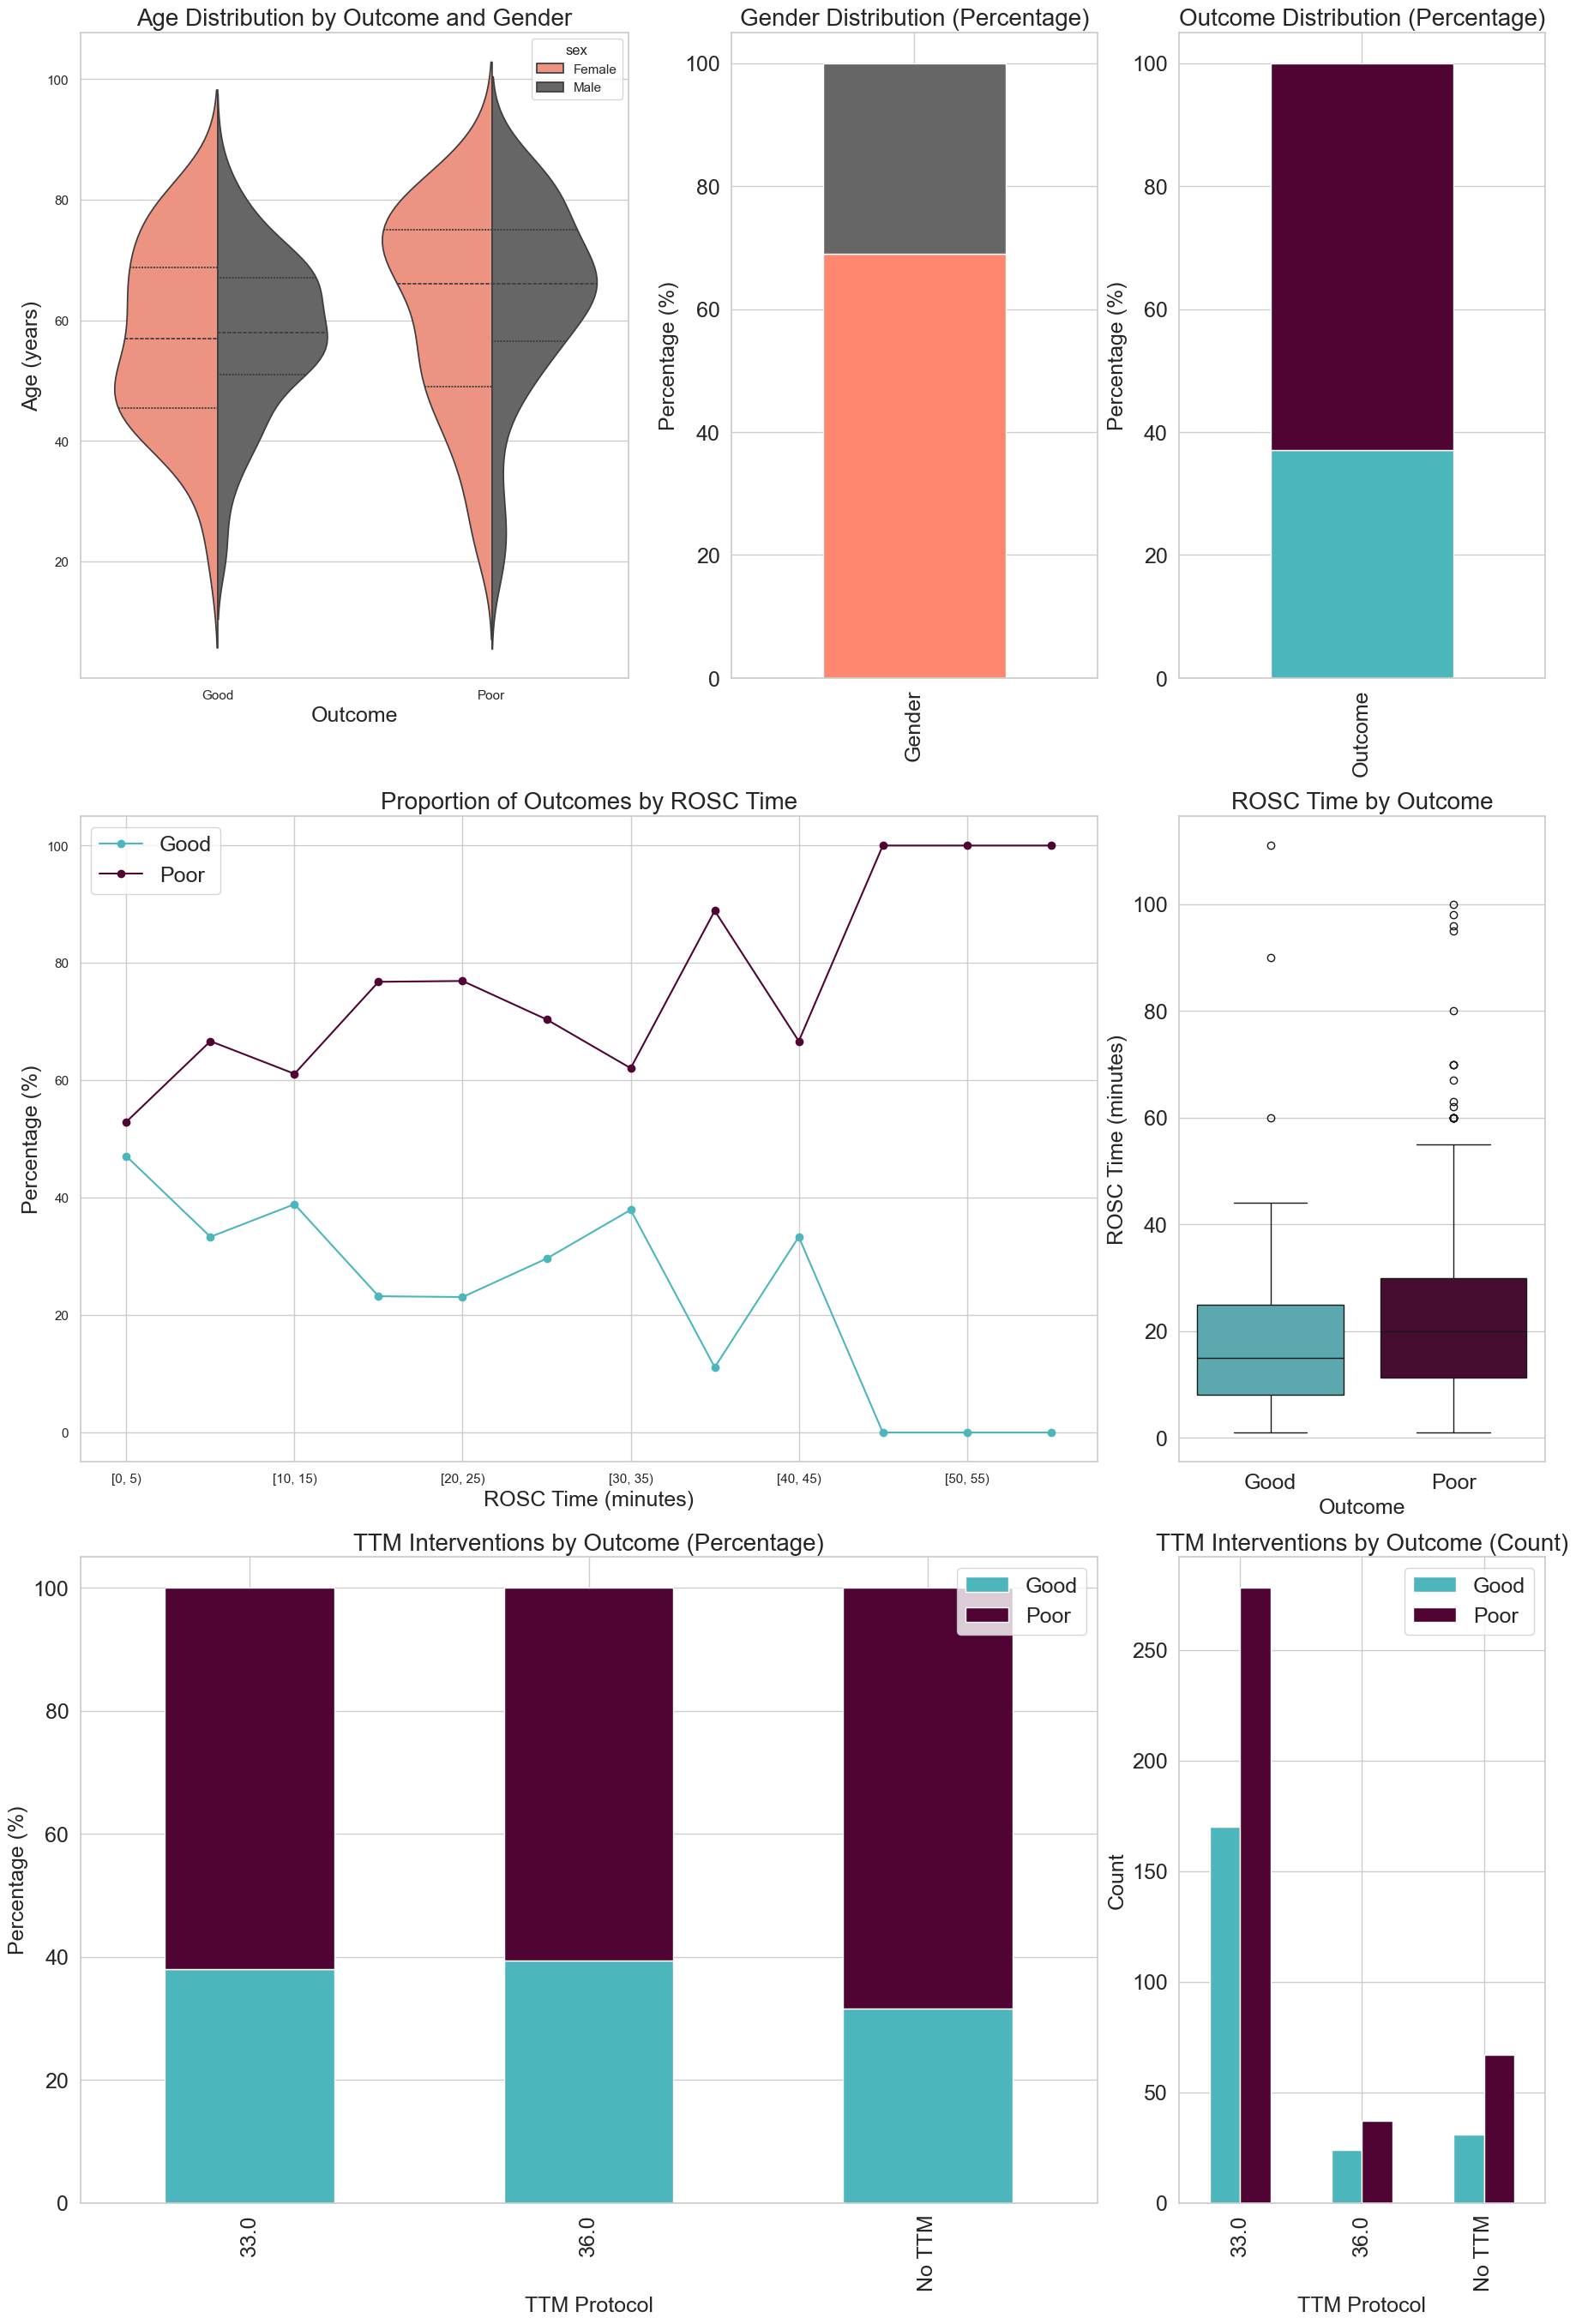

In [74]:
# Create ROSC bins
data['rosc_bin'] = pd.cut(data['rosc'], bins=range(0, 61, 5), right=False)

# Calculate gender counts and outcome counts
gender_counts = data['sex'].value_counts()
outcome_counts = data['outcome'].value_counts()

# Plot Configuration
fig = plt.figure(figsize=(18, 27), constrained_layout=True, facecolor='none')  # Transparent background
gs = fig.add_gridspec(3, 3, width_ratios=[1.5, 1, 1], height_ratios=[1, 1, 1])

# Define a larger font size
font_size = 20
legend_font_size = 18
axis_font_size = 18

# 1st Row, 1st Col: Violin Plot for Age Distribution
ax1 = fig.add_subplot(gs[0, 0])
sns.violinplot(data=data, x="outcome", y="age", hue="sex", split=True, inner="quartile", palette=[KI_COLORS['orange'], KI_COLORS['grey']], ax=ax1)
ax1.set_title('Age Distribution by Outcome and Gender', fontsize=font_size)
ax1.set_xlabel('Outcome', fontsize=axis_font_size)
ax1.set_ylabel('Age (years)', fontsize=axis_font_size)

# 1st Row, 2nd Col: Gender Distribution (Stacked Bar)
ax2 = fig.add_subplot(gs[0, 1])

# Prepare data for gender distribution
gender_data = pd.DataFrame({
    'Male': [gender_counts['Male']],
    'Female': [gender_counts['Female']]
}, index=['Gender'])

# Normalize for 100% stacking
gender_data_percent = gender_data.div(gender_data.sum(axis=1), axis=0) * 100

# Plot single stacked bar for gender
gender_data_percent.plot(kind='bar', stacked=True, ax=ax2, color=[KI_COLORS['orange'], KI_COLORS['grey']])
ax2.set_title('Gender Distribution (Percentage)', fontsize=font_size)
ax2.set_ylabel('Percentage (%)', fontsize=axis_font_size)
ax2.tick_params(axis='x', labelsize=axis_font_size)
ax2.tick_params(axis='y', labelsize=axis_font_size)
ax2.get_legend().remove()

# 1st Row, 3rd Col: Outcome Distribution (Stacked Bar)
ax3 = fig.add_subplot(gs[0, 2])

# Prepare data for outcome distribution
outcome_data = pd.DataFrame({
    'Good': [outcome_counts['Good']],
    'Poor': [outcome_counts['Poor']]
}, index=['Outcome'])

# Normalize for 100% stacking
outcome_data_percent = outcome_data.div(outcome_data.sum(axis=1), axis=0) * 100

# Plot single stacked bar for outcome
outcome_data_percent.plot(kind='bar', stacked=True, ax=ax3, color=[KI_COLORS['blue'], KI_COLORS['plum']])
ax3.set_title('Outcome Distribution (Percentage)', fontsize=font_size)
ax3.set_ylabel('Percentage (%)', fontsize=axis_font_size)
ax3.tick_params(axis='x', labelsize=axis_font_size)
ax3.tick_params(axis='y', labelsize=axis_font_size)
ax3.get_legend().remove()

# 2nd Row, Spanning Columns 1 and 2: Line Plot for ROSC Proportions
ax4 = fig.add_subplot(gs[1, :2])
rosc_outcome = data.groupby('rosc_bin', observed=False)['outcome'].value_counts(normalize=True).unstack() * 100
rosc_outcome.plot(ax=ax4, kind='line', marker='o', color=[KI_COLORS['blue'], KI_COLORS['plum']])
ax4.set_title('Proportion of Outcomes by ROSC Time', fontsize=font_size)
ax4.set_xlabel('ROSC Time (minutes)', fontsize=axis_font_size)
ax4.set_ylabel('Percentage (%)', fontsize=axis_font_size)
ax4.legend(fontsize=legend_font_size)

# 2nd Row, 3rd Col: Boxplot for ROSC Time
ax5 = fig.add_subplot(gs[1, 2])
valid_data = data[data['rosc'].notna()]
sns.boxplot(data=valid_data, x='outcome', y='rosc', palette=[KI_COLORS['blue'], KI_COLORS['plum']], ax=ax5)
ax5.set_title('ROSC Time by Outcome', fontsize=font_size)
ax5.set_xlabel('Outcome', fontsize=axis_font_size)
ax5.set_ylabel('ROSC Time (minutes)', fontsize=axis_font_size)
ax5.tick_params(axis='x', labelsize=axis_font_size)
ax5.tick_params(axis='y', labelsize=axis_font_size)

# 3rd Row, Spanning Columns 1 and 2: TTM Interventions (Percentage)
ax6 = fig.add_subplot(gs[2, :2])
ttm_counts = data.groupby(['ttm', 'outcome'], observed=False).size().unstack(fill_value=0)
ttm_percentages = ttm_counts.div(ttm_counts.sum(axis=1), axis=0) * 100
ttm_percentages.plot(kind='bar', stacked=True, color=[KI_COLORS['blue'], KI_COLORS['plum']], ax=ax6)
ax6.set_title('TTM Interventions by Outcome (Percentage)', fontsize=font_size)
ax6.set_xlabel('TTM Protocol', fontsize=axis_font_size)
ax6.set_ylabel('Percentage (%)', fontsize=axis_font_size)
ax6.tick_params(axis='x', labelsize=axis_font_size)
ax6.tick_params(axis='y', labelsize=axis_font_size)
ax6.legend(fontsize=legend_font_size)

# 3rd Row, 3rd Col: TTM Interventions (Count)
ax7 = fig.add_subplot(gs[2, 2])
ttm_counts.plot(kind='bar', color=[KI_COLORS['blue'], KI_COLORS['plum']], ax=ax7)
ax7.set_title('TTM Interventions by Outcome (Count)', fontsize=font_size)
ax7.set_xlabel('TTM Protocol', fontsize=axis_font_size)
ax7.set_ylabel('Count', fontsize=axis_font_size)
ax7.tick_params(axis='x', labelsize=axis_font_size)
ax7.tick_params(axis='y', labelsize=axis_font_size)
ax7.legend(fontsize=legend_font_size)

# Save and Show
plt.savefig('graphics/eda_summary_transparent.svg', format='svg', transparent=True)  # Set transparent=True
plt.show()
